# I - Preamble

**April 2026 - Ana Rita Carvalho**

(ana.rita.carvalho@tecnico.ulisboa.pt)

This notebook uses Energy Flow Polynomials in different classification models. The datasets used for computing the EFPs and training the models correspond to a dijet background and a di-higgs hh-4b signal (available [here](https://data.mendeley.com/datasets/v9z86dp9mv/1))

In [1]:
# Install uproot and awkward array package
!pip install uproot awkward

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.8/395.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.6/919.6 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 656.7/656.7 kB 18.7 MB/s eta 0:00:00


In [2]:
# Install EnergyFlow package
!pip install energyflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 700.8/700.8 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 503.2/503.2 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 45.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is in

In [1]:
# Install vector package
!pip install vector

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.2/181.2 kB 6.5 MB/s eta 0:00:00


In [2]:
# Install pandas for akward arrays
!pip install awkward-pandas

In [3]:
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 40.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wasserstein 1.1.0 requires numpy<2.0.0,>=1.12.0, but you have numpy 2.0.2 which is incompatible.


In [1]:
# Import packages
import shap
import uproot
import energyflow as ef
import numpy as np
import awkward as ak
import vector
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats
from statsmodels.stats.proportion import proportion_confint

from energyflow.archs import LinearClassifier
from energyflow.archs import DNN
from energyflow.datasets import qg_jets
from energyflow.utils import data_split, standardize, to_categorical
from energyflow.archs import PFN
from energyflow.utils import data_split, remap_pids, to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, accuracy_score, roc_auc_score, roc_curve, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow import keras
from tqdm.notebook import tqdm
from tensorflow.keras.models import Model
from tensorflow.keras import layers, losses
from tensorflow.keras.callbacks import Callback
from keras.callbacks import EarlyStopping
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import pad_sequences
from keras import backend as K

import random
import itertools as it
import time
import joblib
from datetime import datetime

In [2]:
# Mounting google drive on the local repository in order to import files into google colab
from google.colab import drive
drive.mount('/content/gdrive')
%cd gdrive/MyDrive/PPES_samples_test/Energy_Flow/Data

Mounted at /content/gdrive
/content/gdrive/MyDrive/PPES_samples_test/Energy_Flow/Data


# II - Read files

In [3]:
# Open root file with dijet background and hh4b signal events with uproot
bkg_file = uproot.open("dijet_200_ntuple.root")
sig_file = uproot.open("hh4b_200_ntuple.root")

In [4]:
# Retrieve TTree 'ntuple' where the background data is stored and check the existing variables
bkg_ntuple = uproot.open("dijet_200_ntuple.root:ntuple")
bkg_file['ntuple'].show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
eventNumber          | int32_t                  | AsDtype('>i4')
akt_len              | int32_t                  | AsDtype('>i4')
akt_truthEnergy      | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_energy           | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_truthRecoDeltaR  | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Energy     | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Eem        | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Ehad       | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Energy     | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Eem        | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Ehad       | std::vector<float>       | AsJagged(A

In [5]:
# Retrieve TTree 'ntuple' where the signal data is stored and check the existing variables
sig_ntuple = uproot.open("hh4b_200_ntuple.root:ntuple")
sig_file['ntuple'].show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
eventNumber          | int32_t                  | AsDtype('>i4')
akt_len              | int32_t                  | AsDtype('>i4')
akt_truthEnergy      | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_energy           | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_truthRecoDeltaR  | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Energy     | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Eem        | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone01Ehad       | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Energy     | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Eem        | std::vector<float>       | AsJagged(AsDtype('>f4'), he...
akt_cone12Ehad       | std::vector<float>       | AsJagged(A

# III - Retrieve features

## 1- Offline Jets

Reco jets were reconstructed using the anti-kT algorithm, and are used as a proxy for the offline reconstruction.

In [6]:
# Retrieve events as awkward arrays of hadronic coordinates [E, eta, phi] and other relevant features
bkg_events = bkg_ntuple.arrays(['eventNumber', 'akt_energy', 'akt_eta', 'akt_cone04Energy','akt_cone12Energy', 'akt_cone34Energy', 'akt_phi', 'akt_len', 'akt_isPileup','akt_flavor'])
sig_events = sig_ntuple.arrays(['eventNumber', 'akt_energy', 'akt_eta', 'akt_cone04Energy','akt_cone12Energy', 'akt_cone34Energy', 'akt_phi', 'akt_len', 'akt_isPileup','akt_flavor'])

In [ ]:
# _events is an array of events where each event has several arrays, each corresponding to one feature
sig_events

<Array [{eventNumber: 0, ...}, ..., {...}] type='100000 * {eventNumber: int...'>

In [ ]:
# Check if the jets in the events are ordered by pT (they are not)
sig_events[5]['akt_energy']

<Array [62.7, 55.1, 48.8, 47.2, ..., 23.3, 22.3, 24.9] type='17 * float32'>

In [7]:
# Reshape arrays so that each event is a collection of jets (massless jets, pT=Et)
# and convert to vector
vector.register_awkward()
background = ak.zip(
    {
        "nJets": bkg_events.akt_len,
        "pt": bkg_events.akt_energy,
        "eta": bkg_events.akt_eta,
        "phi": bkg_events.akt_phi,
        "Pileup": bkg_events.akt_isPileup,
        "Flavour": bkg_events.akt_flavor,
        "ConeEnergy": bkg_events.akt_cone04Energy,
        "ring34Energy": bkg_events.akt_cone34Energy,
        "ring12Energy": bkg_events.akt_cone12Energy,
        "mass": ak.zeros_like(bkg_events.akt_energy)
}, with_name="Momentum4D")

signal = ak.zip(
    {
        "nJets": sig_events.akt_len,
        "pt": sig_events.akt_energy,
        "eta": sig_events.akt_eta,
        "phi": sig_events.akt_phi,
        "Pileup": sig_events.akt_isPileup,
        "Flavour": sig_events.akt_flavor,
        "ConeEnergy": sig_events.akt_cone04Energy,
        "ring34Energy": sig_events.akt_cone34Energy,
        "ring12Energy": sig_events.akt_cone12Energy,
        "mass": ak.zeros_like(sig_events.akt_energy)
}, with_name="Momentum4D")

# Retrieve the rapidity from the vectors
bkg_y  = background.rapidity
sig_y  = signal.rapidity

# Add y to the arrays
background = ak.with_field(background, bkg_y, "y")
signal = ak.with_field(signal, sig_y, "y")

## 2 - Trigger Jets

Trigger jets were reconstructed using a simplified sliding window algorithm, and are used as a proxy for the L1 trigger reconstruction.

In [8]:
# Retrieve events features as awkward arrays
bkg_events_sw = bkg_ntuple.arrays(['sw_cone04Energy', 'sw_cone34Energy','sw_cone12Energy', 'sw_eta', 'sw_phi', 'sw_isAKTMatched', 'sw_aktEnergy', 'sw_len'])
sig_events_sw = sig_ntuple.arrays(['sw_cone04Energy', 'sw_cone34Energy', 'sw_cone12Energy','sw_eta', 'sw_phi', 'sw_isAKTMatched', 'sw_aktEnergy', 'sw_len'])

In [9]:
# Reshape arrays so that each event is a collection of jets (massless jets, pT=Et)
# and convert to vector
vector.register_awkward()

background_sw = ak.zip(
    {
        "nJets": bkg_events_sw.sw_len,
        "isMatched": bkg_events_sw.sw_isAKTMatched,
        "pt": bkg_events_sw.sw_cone04Energy,
        "ring34Energy": bkg_events_sw.sw_cone34Energy,
        "ring12Energy": bkg_events_sw.sw_cone12Energy,
        "aktEnergy": bkg_events_sw.sw_aktEnergy,
        "eta": bkg_events_sw.sw_eta,
        "phi": bkg_events_sw.sw_phi,
        "mass": ak.zeros_like(bkg_events_sw.sw_cone04Energy)
    }, with_name="Momentum4D"
)

signal_sw = ak.zip(
    {
        "nJets": sig_events_sw.sw_len,
        "isMatched": sig_events_sw.sw_isAKTMatched,
        "pt": sig_events_sw.sw_cone04Energy,
        "ring34Energy": sig_events_sw.sw_cone34Energy,
        "ring12Energy": sig_events_sw.sw_cone12Energy,
        "aktEnergy": sig_events_sw.sw_aktEnergy,
        "eta": sig_events_sw.sw_eta,
        "phi": sig_events_sw.sw_phi,
        "mass": ak.zeros_like(sig_events_sw.sw_cone04Energy)
    }, with_name="Momentum4D"
)

# Add y to the arrays
bkg_y_sw  = background_sw.rapidity
sig_y_sw  = signal_sw.rapidity

background_sw = ak.with_field(background_sw, bkg_y_sw, "y")
signal_sw = ak.with_field(signal_sw, sig_y_sw, "y")

In [ ]:
# Check final structure of the events
background_sw[0]

<MomentumArray4D [{nJets: 54, isMatched: 0, ...}, ...] type='54 * Momentum4...'>

## 3 - Order jets by pT (offline)

In [ ]:
# Retrieve events as pandas DataFrames
background_df = bkg_ntuple.arrays(['akt_energy', 'akt_eta', 'akt_phi', 'eventNumber', 'akt_len','akt_isPileup', 'akt_flavor'], library="pd")
signal_df = sig_ntuple.arrays(['akt_energy', 'akt_eta', 'akt_phi', 'eventNumber', 'akt_len','akt_isPileup','akt_flavor'], library="pd")

In [ ]:
# Check the result
background_df

,akt_energy,akt_eta,akt_phi,eventNumber,akt_len,akt_isPileup,akt_flavor
0,"[56.376060485839844, 49.61208724975586, 40.160...","[0.21851412951946259, -2.463587999343872, -0.5...","[2.961843252182007, -1.0293755531311035, -1.14...",0,15,"[0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, ...","[21.0, 0.0, 0.0, 21.0, 0.0, 21.0, 0.0, 21.0, 0..."
1,"[47.2717399597168, 42.15198516845703, 39.39305...","[0.9015454053878784, 0.39258599281311035, -0.6...","[-2.9753336906433105, 2.4122893810272217, 1.81...",1,12,"[0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, ...","[1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 21.0, 21.0..."
2,"[77.32997131347656, 65.49691772460938, 59.8499...","[-0.635909378528595, -0.3734756112098694, -0.0...","[-2.6921324729919434, -0.6759181618690491, -2....",2,19,"[1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, ...","[0.0, 0.0, 0.0, 21.0, 0.0, 0.0, 1.0, 0.0, 21.0..."
3,"[53.57494354248047, 50.59023666381836, 50.2220...","[-1.0694591999053955, -1.3038361072540283, -1....","[-2.639137029647827, 0.3129067122936249, 1.044...",3,10,"[0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, ...","[2.0, 21.0, 21.0, 21.0, 21.0, 0.0, 21.0, 0.0, ..."
4,"[52.21803283691406, 49.723968505859375, 38.353...","[-1.3898849487304688, -1.1118090152740479, 0.6...","[2.145557403564453, -0.0785595253109932, 2.994...",4,16,"[1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, ...","[0.0, 0.0, 21.0, 21.0, 0.0, 0.0, 0.0, 0.0, 0.0..."
...,...,...,...,...,...,...,...
99995,"[51.92322540283203, 54.798622131347656, 52.258...","[3.175819158554077, 0.20312269032001495, -0.28...","[-2.738940477371216, 1.4623088836669922, 2.618...",99995,15,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...","[0.0, 3.0, 21.0, 21.0, 2.0, 3.0, 21.0, 21.0, 0..."
99996,"[45.12558364868164, 46.88414001464844, 37.9416...","[-2.9548678398132324, -0.5077465772628784, -0....","[0.03712071478366852, -2.593989133834839, -1.9...",99996,12,"[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 21.0, 21.0, 1.0, 0.0, 21.0, 21.0, 21.0, ..."
99997,"[57.99683380126953, 38.15359878540039, 37.2110...","[-1.5791735649108887, -3.212261199951172, 2.07...","[0.709058403968811, -0.9951223731040955, -1.63...",99997,12,"[1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 21.0, 0.0, 0.0, 21.0..."
99998,"[47.493064880371094, 44.485530853271484, 39.10...","[-0.23593087494373322, 0.7516812682151794, -0....","[0.8830403685569763, -0.44237232208251953, 1.9...",99998,15,"[0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, ...","[21.0, 21.0, 21.0, 21.0, 0.0, 2.0, 0.0, 0.0, 2..."


In [ ]:
# For each event in the DataFrame, sort jets by pt, add a list of event data to the array of all events
# and calculate the invariant mass of the four b-labelled jets (if they exist)

background_ordered = []
true_mHH_bkg = []

for event in range(len(background_df)):
  # Retrieve event data into a DataFrame with jet features as columns and
  # number of rows = number of jets in the event
  event_data = background_df.iloc[event]
  df = pd.DataFrame({"pt": event_data['akt_energy'], "y": event_data['akt_eta'], "phi": event_data['akt_phi'], "flavour": event_data['akt_flavor']})
  # Sort jets by pT
  df = df.sort_values(by=['pt'], ascending=False)
  jets_list = df.values.tolist()
  # Add sorted jets to list of events
  background_ordered.append(jets_list)

  # Select b-labelled jets in the event
  b_jets = df[df['flavour'] == 5]
  b_jets_list = b_jets.values.tolist()
  # Compute four-jet invariant mass for events with (at least) 4 b-labelled jets
  if len(b_jets_list) >= 4:
    # Retrive the four leading b-labelled jets as vector objects
    b1 = vector.obj(pt=b_jets_list[0][0], eta=b_jets_list[0][1], phi=b_jets_list[0][2], mass=0)
    b2 = vector.obj(pt=b_jets_list[1][0], eta=b_jets_list[1][1], phi=b_jets_list[1][2], mass=0)
    b3 = vector.obj(pt=b_jets_list[2][0], eta=b_jets_list[2][1], phi=b_jets_list[2][2], mass=0)
    b4 = vector.obj(pt=b_jets_list[3][0], eta=b_jets_list[3][1], phi=b_jets_list[3][2], mass=0)
    # Sum the four vectors and retrieve vector mass
    bbbb = b1 + b2 + b3 + b4
    true_mHH_bkg.append(bbbb.mass)
  # Placeholder for events with less than 4 b-labelled jets
  else:
    true_mHH_bkg.append(0)

# Repeat for signal events
signal_ordered = []
true_mHH_sig = []

for event in range(len(signal_df)):
  event_data = signal_df.iloc[event]
  df = pd.DataFrame({"pt": event_data['akt_energy'], "y": event_data['akt_eta'], "phi": event_data['akt_phi'], "flavour": event_data['akt_flavor']})
  df = df.sort_values(by=['pt'], ascending=False)
  jets_list = df.values.tolist()
  signal_ordered.append(jets_list)
  b_jets = df[df['flavour'] == 5]
  b_jets_list = b_jets.values.tolist()
  if len(b_jets_list) >= 4:
    b1 = vector.obj(pt=b_jets_list[0][0], eta=b_jets_list[0][1], phi=b_jets_list[0][2], mass=0)
    b2 = vector.obj(pt=b_jets_list[1][0], eta=b_jets_list[1][1], phi=b_jets_list[1][2], mass=0)
    b3 = vector.obj(pt=b_jets_list[2][0], eta=b_jets_list[2][1], phi=b_jets_list[2][2], mass=0)
    b4 = vector.obj(pt=b_jets_list[3][0], eta=b_jets_list[3][1], phi=b_jets_list[3][2], mass=0)
    bbbb = b1 + b2 + b3 + b4
    true_mHH_sig.append(bbbb.mass)
  else:
    true_mHH_sig.append(0)

In [ ]:
# (Run once) Save invariant mass arrays
np.save('true_mHH_bkg.npy', true_mHH_bkg)
np.save('true_mHH_sig.npy', true_mHH_sig)

# IV - Plot features

Plot some of the features to compare offline and trigger jets for signal and background data.

In [10]:
# Increase font size (needed to use plots in reports)
import matplotlib
matplotlib.rcParams.update({'font.size': 14})

## 1 - Jet Multiplicity

In [ ]:
# Retrieve jet number for signal and background events
sig_jet_number = sig_ntuple.arrays(['akt_len'])
bkg_jet_number = bkg_ntuple.arrays(['akt_len'])

# Convert to array
jet_number_offline_sig = [event['akt_len'] for event in ak.to_list(sig_jet_number)]
jet_number_offline_bkg = [event['akt_len'] for event in ak.to_list(bkg_jet_number)]

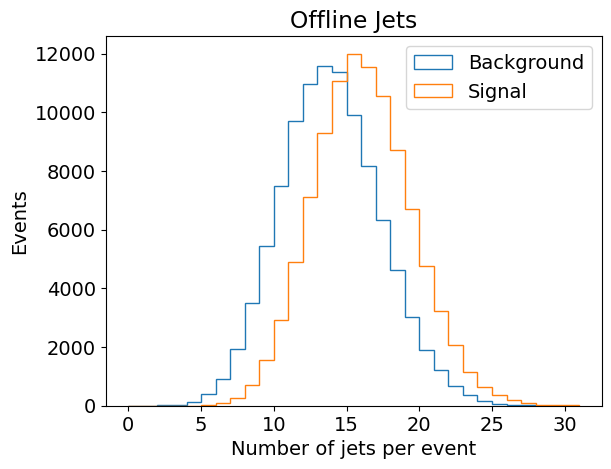

In [ ]:
# Plot jet multiplicity (offline jets)
plt.hist(jet_number_offline_bkg, bins=range(32), histtype='step', label='Background')
plt.hist(jet_number_offline_sig, bins=range(32), histtype='step',label='Signal')
plt.xlabel('Number of jets per event')
plt.ylabel('Events')
plt.title('Offline Jets')
plt.legend()
plt.show()

In [ ]:
# Compute total number of offline jets
totalNjets_offline_bkg = np.sum(jet_number_offline_bkg)
totalNjets_offline_sig = np.sum(jet_number_offline_sig)
print(f'Total number of offline jets in the background: {totalNjets_offline_bkg}')
print(f'Total number of offline jets in the signal: {totalNjets_offline_sig}')

Total number of offline jets in the background: 1343218
Total number of offline jets in the signal: 1562989


In [ ]:
# Check how many signal events have at least 4 jets
jet_number_offline_sig = np.array(jet_number_offline_sig)
condlist = [jet_number_offline_sig >= 4]
choicelist = [1]
sig_events_4jets = np.select(condlist, choicelist, 0)
print(f'Number of signal events with at least 4 jets: {np.sum(sig_events_4jets)}')

Number of signal events with at least 4 jets: 99999


In [ ]:
# Retrieve trigger jet number for signal and background events
sig_jet_number = sig_ntuple.arrays(['sw_len'])
bkg_jet_number = bkg_ntuple.arrays(['sw_len'])

# Convert to array
jet_number_trigger_sig = [event['sw_len'] for event in ak.to_list(sig_jet_number)]
jet_number_trigger_bkg = [event['sw_len'] for event in ak.to_list(bkg_jet_number)]

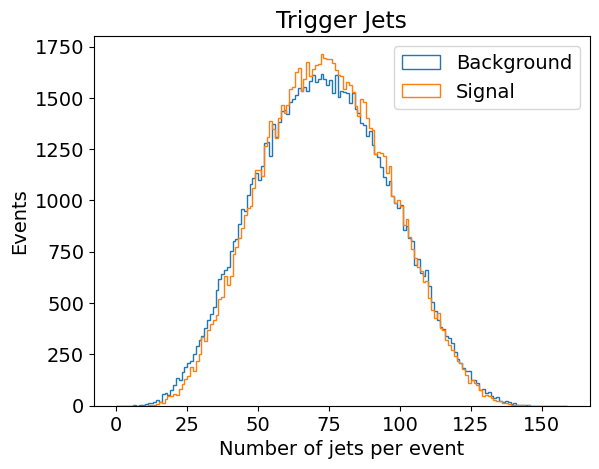

In [ ]:
# Plot jet multiplicity (trigger jets)
plt.hist(jet_number_trigger_bkg, bins=range(160), histtype='step', label='Background')
plt.hist(jet_number_trigger_sig, bins=range(160), histtype='step',label='Signal')
plt.xlabel('Number of jets per event')
plt.ylabel('Events')
plt.title('Trigger Jets')
plt.legend()
plt.show()

In [ ]:
# Compute total number of trigger jets
totalNjets_trigger_bkg = np.sum(jet_number_trigger_bkg)
totalNjets_trigger_sig = np.sum(jet_number_trigger_sig)
print(f'Total number of trigger jets in the background: {totalNjets_trigger_bkg}')
print(f'Total number of trigger jets in the signal: {totalNjets_trigger_sig}')

Total number of trigger jets in the background: 7273053
Total number of trigger jets in the signal: 7338728


## 2 - Jet Energy

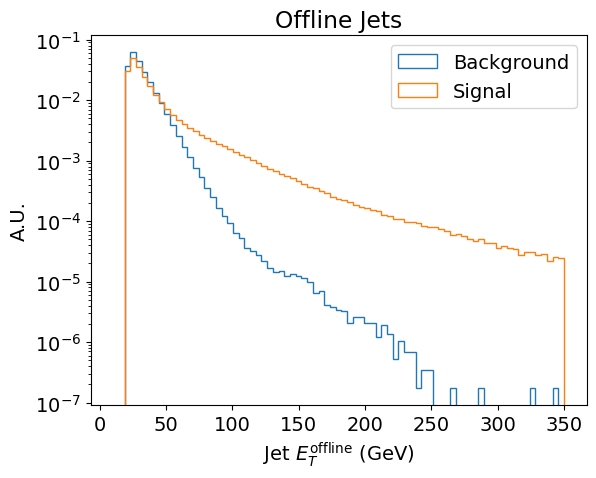

In [ ]:
# Plot jet pT (offline)
plt.hist(ak.flatten(background.pt), bins = np.linspace(10,350,80), histtype='step', label='Background', density=True)
plt.hist(ak.flatten(signal.pt), bins = np.linspace(10,350,80), histtype='step',label='Signal', density=True)
plt.xlabel(r'Jet $E_{T}^{\mathrm{offline}}$ (GeV)')
plt.title('Offline Jets')
plt.ylabel('A.U.')
plt.yscale('log')
plt.legend()
plt.show()

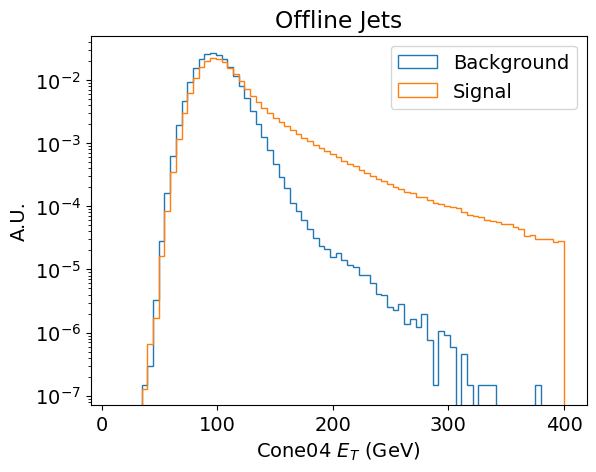

In [12]:
# Plot jet pT (offline)
plt.hist(ak.flatten(background.ConeEnergy), bins = np.linspace(10,400,80), histtype='step', label='Background', density=True)
plt.hist(ak.flatten(signal.ConeEnergy), bins = np.linspace(10,400,80), histtype='step',label='Signal', density=True)
plt.xlabel(r'Cone04 $E_T$ (GeV)')
plt.title('Offline Jets')
plt.ylabel('A.U.')
plt.yscale('log')
plt.legend()
plt.show()

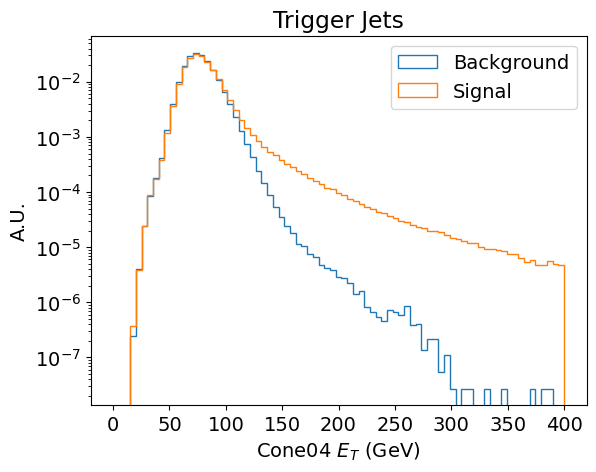

In [ ]:
# Plot jet pT (trigger)
plt.hist(ak.flatten(background_sw.pt), bins = np.linspace(0,400,80), histtype='step', label='Background', density=True)
plt.hist(ak.flatten(signal_sw.pt), bins = np.linspace(0,400,80), histtype='step',label='Signal', density=True)
plt.xlabel(r'Cone04 $E_{T}$ (GeV)')
plt.ylabel('A.U.')
plt.xticks(np.arange(0, 430, 50))
plt.title('Trigger Jets')
plt.yscale('log')
plt.legend()
plt.show()

## 3 - Jet eta and phi

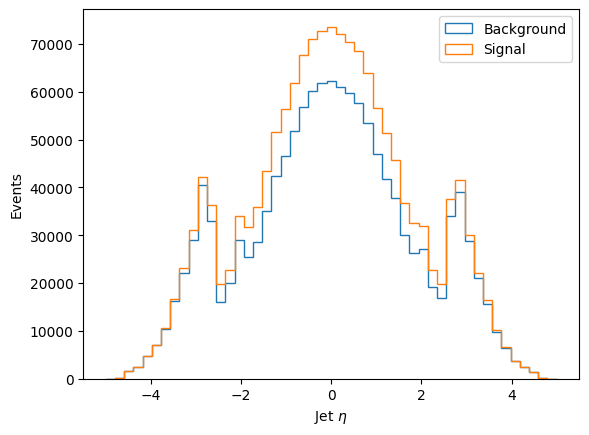

In [ ]:
# Plot offline jet eta
plt.hist(ak.flatten(background.eta), bins = np.linspace(-5,5,50), histtype='step', label='Background')
plt.hist(ak.flatten(signal.eta), bins = np.linspace(-5,5,50), histtype='step',label='Signal')
plt.xlabel(r'Jet $\eta$')
plt.ylabel('Events')
plt.legend()
plt.show()

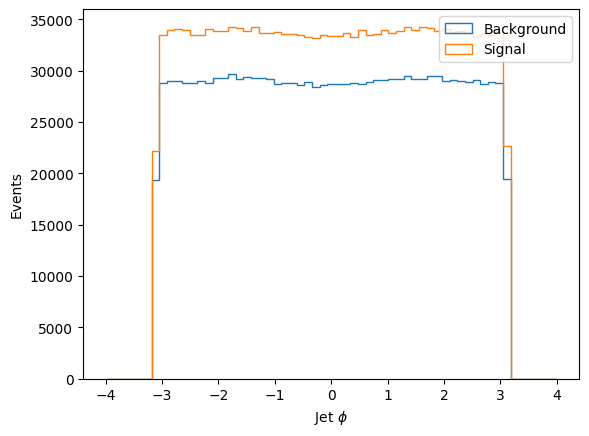

In [ ]:
# Plot offline jet phi
plt.hist(ak.flatten(background.phi), bins = np.linspace(-4,4,60), histtype='step', label='Background')
plt.hist(ak.flatten(signal.phi), bins = np.linspace(-4,4,60), histtype='step',label='Signal')
plt.xlabel(r'Jet $\phi$')
plt.ylabel('Events')
plt.legend(loc='upper right')
plt.show()

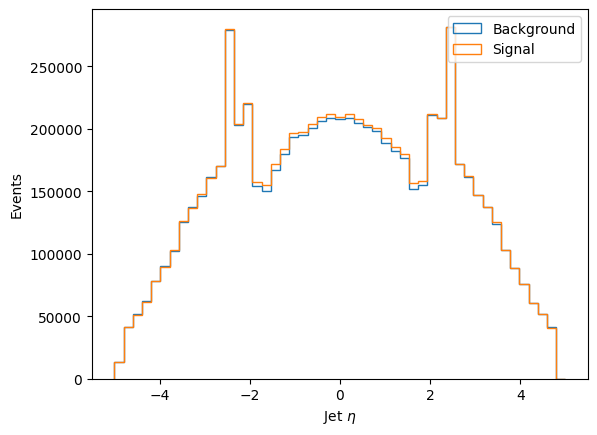

In [ ]:
# Plot trigger jet eta
plt.hist(ak.flatten(background_sw.eta), bins = np.linspace(-5,5,50), histtype='step', label='Background')
plt.hist(ak.flatten(signal_sw.eta), bins = np.linspace(-5,5,50), histtype='step',label='Signal')
plt.xlabel(r'Jet $\eta$')
plt.ylabel('Events')
plt.legend(loc='upper right')
plt.show()

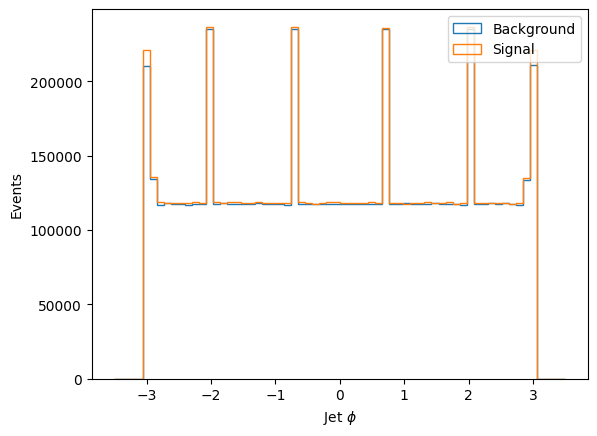

In [ ]:
# Plot trigger jet phi
plt.hist(ak.flatten(background_sw.phi), bins = np.linspace(-3.5,3.5,65), histtype='step', label='Background')
plt.hist(ak.flatten(signal_sw.phi), bins = np.linspace(-3.5,3.5,65), histtype='step',label='Signal')
plt.xlabel(r'Jet $\phi$')
plt.ylabel('Events')
plt.legend(loc='upper right')
plt.show()

## 4 - Invariant mass

In [13]:
true_mass_bkg = np.load('true_mHH_bkg.npy')
true_mass_sig = np.load('true_mHH_sig.npy')

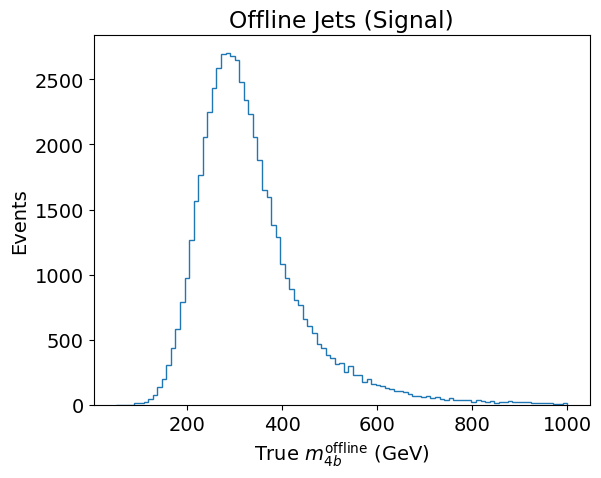

In [16]:
# Plot invariant mass (offline) of the four leading jets
#plt.hist(true_mass_bkg, bins = np.linspace(50,1000,100), histtype='step', label='Background')
plt.hist(true_mass_sig, bins = np.linspace(50,1000,100), histtype='step')
plt.xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
plt.title('Offline Jets (Signal)')
plt.ylabel('Events')
plt.show()

## 5 - PU and HS offline jets

In [19]:
# Background
# Select pile-up jets
bkg_pile_up = background[background.Pileup == 1]
bkg_pu_b_jets = bkg_pile_up[bkg_pile_up.Flavour == 5]

# Determine number of pile-up jets in each event
bkg_pile_up_number = []
for event in range(len(bkg_pu_b_jets)):
    pu_jets_number = len(bkg_pu_b_jets[event])
    bkg_pile_up_number.append(pu_jets_number)

# Select hard-scatter jets and determine the number in each event
bkg_hard_scatter = background[background.Pileup == 0]
bkg_hard_scatter_b_jets = bkg_hard_scatter[bkg_hard_scatter.Flavour == 5]
bkg_hard_scatter_number = []
for event in range(len(bkg_hard_scatter_b_jets)):
    hs_jets_number = len(bkg_hard_scatter_b_jets[event])
    bkg_hard_scatter_number.append(hs_jets_number)

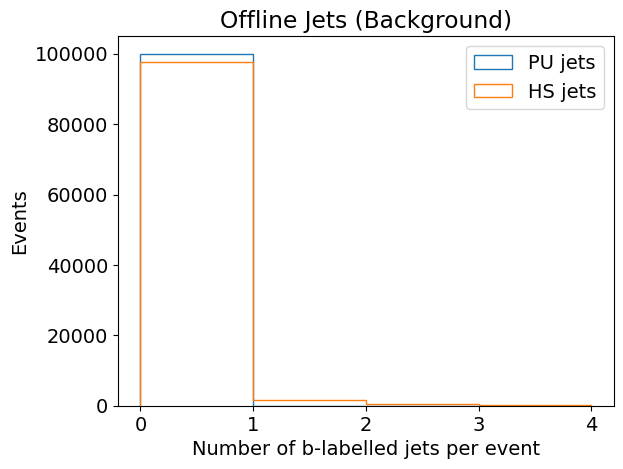

In [24]:
# Plot histogram
binwidth = 1
plt.hist(bkg_pile_up_number, bins=range(5), histtype='step', label='PU jets')
plt.hist(bkg_hard_scatter_number, bins=range(5), histtype='step', label='HS jets')
plt.legend()
plt.title('Offline Jets (Background)')
plt.xlabel('Number of b-labelled jets per event')
plt.ylabel('Events')
plt.show()

In [25]:
# Signal
# Select pile-up jets and determine number per event
sig_pile_up = signal[signal.Pileup == 1]
sig_pu_b_jets = sig_pile_up[sig_pile_up.Flavour == 5]
sig_pile_up_number = []
for event in range(len(sig_pu_b_jets)):
    pu_jets_number = len(sig_pu_b_jets[event])
    sig_pile_up_number.append(pu_jets_number)

# Select hard scatter jets and determine number per event
sig_hard_scatter = signal[signal.Pileup == 0]
sig_hard_scatter_b_jets = sig_hard_scatter[sig_hard_scatter.Flavour == 5]
sig_hard_scatter_number = []
for event in range(len(sig_hard_scatter_b_jets)):
    hs_jets_number = len(sig_hard_scatter_b_jets[event])
    sig_hard_scatter_number.append(hs_jets_number)

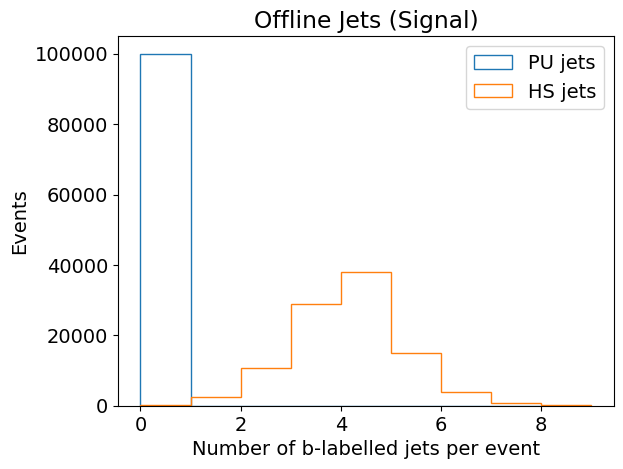

In [27]:
# Plot histogram
binwidth = 1
plt.hist(sig_pile_up_number, bins=range(10), histtype='step', label='PU jets')
plt.hist(sig_hard_scatter_number, bins=range(10), histtype='step', label='HS jets')
plt.legend()
plt.title('Offline Jets (Signal)')
plt.xlabel('Number of b-labelled jets per event')
plt.ylabel('Events')
plt.show()

## 6 - Trigger Matched Jets

In [28]:
# Retrieve jets matched with offline jets
bkg_match = background_sw[background_sw.isMatched == 1]
sig_match = signal_sw[signal_sw.isMatched == 1]

# Determine number of matched jets in each event
bkg_match_number = []
for event in range(len(bkg_match)):
  matched_jets_number = len(bkg_match[event])
  bkg_match_number.append(matched_jets_number)

sig_match_number = []
for event in range(len(sig_match)):
  matched_jets_number = len(sig_match[event])
  sig_match_number.append(matched_jets_number)

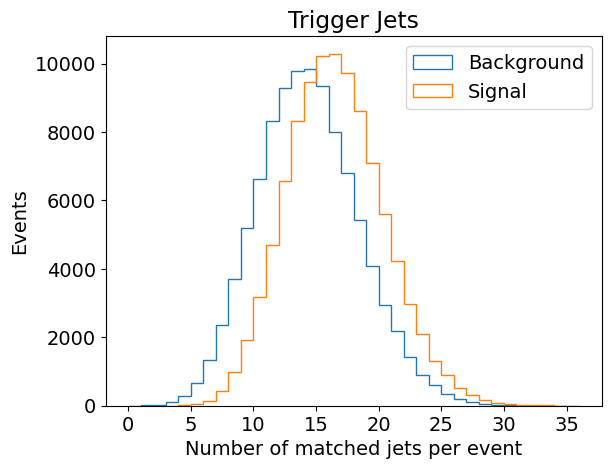

In [29]:
# Plot histogram
binwidth = 1
plt.hist(bkg_match_number, bins=range(min(bkg_match_number), max(bkg_match_number) + binwidth, binwidth), histtype='step', label='Background')
plt.hist(sig_match_number, bins=range(min(sig_match_number), max(sig_match_number) + binwidth, binwidth), histtype='step', label='Signal')
plt.legend()
plt.title('Trigger Jets')
plt.xlabel('Number of matched jets per event')
plt.ylabel('Events')
plt.show()

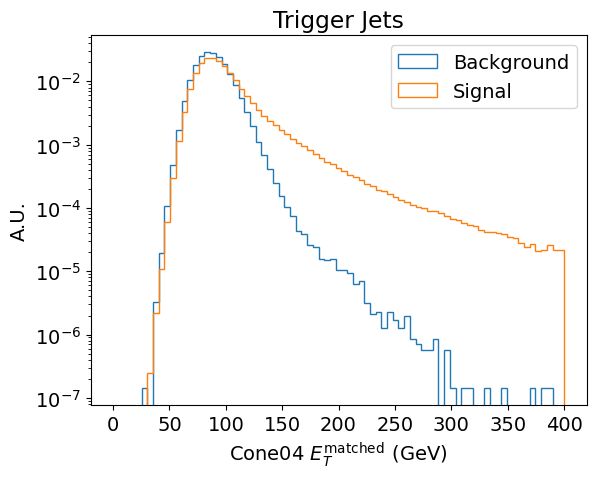

In [30]:
# Plot histogram of the jets pT
plt.hist(ak.flatten(bkg_match.pt), bins=np.linspace(0,400,80), histtype='step', label='Background', density=True)
plt.hist(ak.flatten(sig_match.pt), bins=np.linspace(0,400,80), histtype='step', label='Signal', density=True)
plt.legend()
plt.title('Trigger Jets')
plt.xlabel(r'Cone04 $E_{T}^{\mathrm{matched}} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('A.U.')
plt.yscale('log')
plt.xticks(np.arange(0, 430, 50))
plt.show()

# V - Compute EFPs

In [ ]:
# Define some parameters of the EFPs
dmax = 6
measure = 'hadr'
beta = 1
test_frac = 0.2
colors = ['tab:red', 'tab:orange', 'tab:olive', 'tab:green', 'tab:blue', 'tab:purple']

# Define set of graphs
efpset = ef.EFPSet(('d<=',6), measure='hadr',  beta=beta)

## 1 - Offline Jets

In [ ]:
# Convert to arrays that can be used by EnergyFlow with coordinates (pT,y,phi)
bkg_data_pfn = [
    [[jet['pt'], jet['eta'], jet['phi']] for jet in event]
    for event in background
]

sig_data_pfn = [
    [[jet['pt'], jet['eta'], jet['phi']] for jet in event]
    for event in signal
]

data_efp = bkg_data_pfn + sig_data_pfn

In [ ]:
# Calculate all EFPs with d<=dmax
print('Calculating d <= {} EFPs'.format(dmax), end='')
efpset = ef.EFPSet(('d<=',6), measure='hadr',  beta=beta)
X_EFP = efpset.batch_compute(data_efp)
print('Done')

# Save results
np.save('efps_dmax6.npy', X_EFP)

In [ ]:
# Retrieve energy of the fourth leading jet
data = ak.concatenate([background, signal])
pt_fourth_leading_jet = []
for event in data:
  if len(event) < 4:
    pt_fourth_leading_jet.append(0)
  else:
    jet_4 = event[3]
    pt_4 = jet_4[0]
    pt_fourth_leading_jet.append(pt_4)
np.save('pt4_offline.npy', pt_fourth_leading_jet)

## 2 - Trigger Jets

In [144]:
data_sw = ak.concatenate([bkg_match, sig_match])

In [145]:
bkg_efp_sw = []
for event in bkg_match:
  event = sorted(event, key=lambda j: j.pt, reverse=True)
  event_data = [[jet['pt'], jet['eta'], jet['phi']] for jet in event]
  bkg_efp_sw.append(event_data)

sig_efp_sw = []
for event in sig_match:
  event = sorted(event, key=lambda j: j.pt, reverse=True)
  event_data = [[jet['pt'], jet['eta'], jet['phi']] for jet in event]
  sig_efp_sw.append(event_data)

In [158]:
data_pfn_all = bkg_efp_sw + sig_efp_sw

# Remove events with no matched jet (and remove corresponding pt4 offline and mass)
pt4_offline_all = np.load('pt4_offline.npy')
true_mass_bkg = np.load('true_mHH_bkg.npy')
true_mass_sig = np.load('true_mHH_sig.npy')
true_mass_offline_all = np.concatenate([true_mass_bkg, true_mass_sig])
data_pfn = []
pt4_offline = []
true_mass_offline = []

for i in range(len(data_pfn_all)):
  if len(data_pfn_all[i]) != 0:
    data_pfn.append(data_pfn_all[i])
    pt4_offline.append(pt4_offline_all[i])
    true_mass_offline.append(true_mass_offline_all[i])
pt4_offline = np.array(pt4_offline)
true_mass_offline = np.array(true_mass_offline)

In [159]:
# Remove events with no matched jets
bkg_efp_sw = [event for event in bkg_efp_sw if event]
sig_efp_sw = [event for event in sig_efp_sw if event]

# Create arrays with the labels
bkg_labels = np.zeros(len(bkg_efp_sw))
sig_labels = np.ones(len(sig_efp_sw))

# Combine jet data and labels
y = np.concatenate([bkg_labels, sig_labels])

In [ ]:
# Calculate all EFPs with d<=dmax
dmax = 5
print('Calculating d <= {} EFPs'.format(dmax), end='')

efpset = ef.EFPSet(('d<=', dmax), measure=measure, beta=beta)
X_dmax5 = efpset.batch_compute(data_efp_sw)
print('Done')

# Save results
np.save('efps_L1_dmax5.npy', X_dmax5)

Calculating d <= 5 EFPsDone


In [ ]:
# Calculate all EFPs with d=6
print('Calculating d = {} EFPs'.format(6), end='')
efpset6 = ef.EFPSet(('d==6'), measure='hadr',  beta=beta)
X_dim6 = efpset6.batch_compute(data_efp)
print('Done')

np.save('efps_L1_dim6.npy', X_dim6)

Calculating d = 6 EFPsDone


# VI - Load data

In [31]:
# Define some parameters of the EFPs
dmax = 5
measure = 'hadr'
beta = 1
test_frac = 0.2
colors = ['tab:red', 'tab:orange', 'tab:olive', 'tab:green', 'tab:blue', 'tab:purple']

# Define set of graphs
efpset = ef.EFPSet(('d<=', 5), measure='hadr',  beta=beta)
#efpset6 = ef.EFPSet(('d==6'), measure='hadr',  beta=beta)

In [32]:
# Load data with EFPs (Offline)
X_dim5 = np.load('efps_reco_beta1.npy') # EFPs with d<=5
X_dim6 = np.load('efps_dim6.npy') # EFPs with d=6
X_EFP = np.concatenate([X_dim5, X_dim6], axis=1) # EFPs with d<=6

In [149]:
# Load data with EFPs (L1 trigger)
X_dim5 = np.load('efps_L1_dmax5.npy') # EFPs with d<=5
X_dim6 = np.load('efps_L1_dim6.npy') # EFPs with d=6
X_EFP = np.concatenate([X_dim5, X_dim6], axis=1) # EFPs with d<=6

In [33]:
# Create arrays with the labels
bkg_labels = np.zeros(len(background))
sig_labels = np.ones(len(signal))
y = np.concatenate([bkg_labels, sig_labels])

In [60]:
# Load data with fourth leading jet pt and true 4b mass
pt4_offline = np.load('pt4_offline.npy')

true_mass_bkg = np.load('true_mHH_bkg.npy')
true_mass_sig = np.load('true_mHH_sig.npy')
true_mass = np.concatenate([true_mass_bkg, true_mass_sig])

# VII - Define functions

In [36]:
"""
plot_scores: plots the output scores distribution for signal and background.
The function takes as input two arrays, corresponding to the background and
signal scores and plots them in a histogram.
"""
def plot_scores(preds_bkg, preds_sig):
  plt.hist(preds_bkg, bins=np.linspace(0,1,200), histtype='step', label='Background')
  plt.hist(preds_sig, bins=np.linspace(0,1,200), histtype='step',label='Signal')
  plt.xlabel('Classifier Output')
  plt.ylabel('Events')
  plt.legend()
  plt.show()

In [134]:
"""
get_threshold: calculates the 5% background acceptance threshold.
The function takes as input the background scores and returns the threshold
that gives a background acceptance of 0.05.
"""
def get_threshold(preds_bkg):
  # Define histogram for bkg scores
  bins = np.linspace(0,1,1000)
  counts, edges = np.histogram(preds_bkg, bins = bins)
  # Calculate histogram integral
  total_integral = np.sum(counts)
  # Calculate the bkg efficiency for each threshold
  thresholds = []
  background_efficiency = []
  bkg_counts = 0
  for i in range(len(counts)):
    bkg_counts += counts[i]
    if total_integral != 0:
      bkg_acceptance = bkg_counts/total_integral
      background_efficiency.append(bkg_acceptance)
      cut = edges[i+1]
      thresholds.append(cut)
      if bkg_acceptance >= 0.95:
        return(cut)

In [38]:
"""
signal_energies: retrieves the energy of the fourth leading jet for all signal events.
The function takes as input the test set and returns an array with the energy of the
fourth leading jet for the signal events.
"""
def signal_energies(X_test, y_test, pt4_test):
  signal_energies = []
  for i in range(len(X_test)):
    if y_test[i] == 1:
      if pt4_test[i] != 0:
        signal_energies.append(pt4_test[i])
  return signal_energies

"""
selected_energies: retrieves the energy of the fourth leading jet for all selected signal events.
The function takes as input the array with the predictions, the threshold and
labels and energy of the test set and returns an array with the energy of the
fourth leading jet for the selected signal events.
"""
def selected_energies(preds, y_test, pt4_test, cut):
  selected_energies = []
  for i in range(len(preds)):
    if preds[i] >= cut and y_test[i] == 1:
      selected_energies.append(pt4_test[i])
  return selected_energies

In [61]:
"""
get_EFP: retrieves the EFP with index i in a efpset.
The function takes as input the efpset and the index of the EFP and returns the
number of vertices and edges (respectively) of the corresponding graph.
"""
def get_EFP(efpset, i):
  i = int(i)
  graph = efpset.graphs(i)
  n, _, d, v, _, c, p, _ = efpset.specs[i]
  return n, d

In [62]:
"""
is_EFP_prime: check if the EFP with index i is prime in a efpset.
The function takes as input the efpset and the index of the EFP and returns 1 if
the EFP is prime and p > 1 otherwise, with p corresponding to the number of prime EFPs
that compose the given EFP.
"""
def is_EFP_prime(efpset, i):
  i = int(i)
  graph = efpset.graphs(i)
  n, _, d, v, _, c, p, _ = efpset.specs[i]
  return p

# VIII - Selection with EFPs

In this section, we apply a cut directly on the EFPs to distinguish signal and background.

## 1 - Correlation Plots

In [71]:
efpset = ef.EFPSet(('d<=', 5), measure=measure, beta=beta)
signal_idx = np.where(y == 1)[0]
bkg_idx    = np.where(y == 0)[0]
EFPs_bkg = []
columns_bkg = []
EFPs_sig = []
columns_sig = []

for i in range(X_dim5.shape[1]):
  i = int(i)
  EFP_bkg = X_dim5[bkg_idx,i]
  EFP_sig = X_dim5[signal_idx,i]
  n, d = get_EFP(efpset, i)
  EFPs_bkg.append(EFP_bkg)
  EFPs_sig.append(EFP_sig)
  columns_bkg.append("EFP {}: n = {}, d = {}".format(i, n, d))
  columns_sig.append("EFP {}: n = {}, d = {}".format(i, n, d))

# create pandas DF with transpose EFPs
df_EFPs_bkg = pd.DataFrame(EFPs_bkg)
df_EFPs_bkg = df_EFPs_bkg.transpose()
df_EFPs_bkg.columns = columns_bkg
df_EFPs_sig = pd.DataFrame(EFPs_sig)
df_EFPs_sig = df_EFPs_sig.transpose()
df_EFPs_sig.columns = columns_sig

In [72]:
# Remove EFP with n= 1 and d = 0 (=1 to all events)
df_EFPs_bkg = df_EFPs_bkg.drop(columns=['EFP 0: n = 1, d = 0'], axis=1)
df_EFPs_sig = df_EFPs_sig.drop(columns=['EFP 0: n = 1, d = 0'], axis=1)

In [73]:
corr_matrix_bkg = df_EFPs_bkg.corr()
corr_matrix_bkg

,"EFP 1: n = 2, d = 1","EFP 2: n = 2, d = 2","EFP 3: n = 2, d = 3","EFP 4: n = 2, d = 4","EFP 5: n = 2, d = 5","EFP 6: n = 3, d = 2","EFP 7: n = 3, d = 3","EFP 8: n = 3, d = 4","EFP 9: n = 3, d = 4","EFP 10: n = 3, d = 5",...,"EFP 92: n = 7, d = 5","EFP 93: n = 7, d = 5","EFP 94: n = 7, d = 5","EFP 95: n = 8, d = 4","EFP 96: n = 8, d = 5","EFP 97: n = 8, d = 5","EFP 98: n = 8, d = 5","EFP 99: n = 8, d = 5","EFP 100: n = 9, d = 5","EFP 101: n = 10, d = 5"
"EFP 1: n = 2, d = 1",1.000000,0.906319,0.659632,0.437303,0.305835,0.923426,0.676744,0.445385,0.437326,0.308246,...,0.294897,0.298650,0.359201,0.447063,0.312901,0.308535,0.309108,0.290892,0.305064,0.301100
"EFP 2: n = 2, d = 2",0.906319,1.000000,0.903154,0.727437,0.588358,0.996427,0.913273,0.734845,0.727456,0.590834,...,0.574298,0.578738,0.628562,0.733091,0.595067,0.589707,0.590595,0.569157,0.585620,0.580665
"EFP 3: n = 2, d = 3",0.659632,0.903154,1.000000,0.944638,0.853343,0.880792,0.998566,0.948285,0.944647,0.854907,...,0.841594,0.845044,0.845548,0.944680,0.856944,0.852656,0.853563,0.837114,0.849585,0.845459
"EFP 4: n = 2, d = 4",0.437303,0.727437,0.944638,1.000000,0.974935,0.696586,0.934316,0.999604,1.000000,0.975435,...,0.968654,0.970395,0.916829,0.996006,0.975163,0.972958,0.973660,0.965881,0.971658,0.969338
"EFP 5: n = 2, d = 5",0.305835,0.588358,0.853343,0.974935,1.000000,0.556035,0.838494,0.971986,0.974930,0.999911,...,0.998500,0.998973,0.909961,0.968904,0.998308,0.997769,0.998272,0.997191,0.997883,0.997061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"EFP 97: n = 8, d = 5",0.308535,0.589707,0.852656,0.972958,0.997769,0.558783,0.839190,0.970835,0.972952,0.998095,...,0.997594,0.998576,0.925172,0.972621,0.999559,1.000000,0.999924,0.996605,0.999872,0.999361
"EFP 98: n = 8, d = 5",0.309108,0.590595,0.853563,0.973660,0.998272,0.559598,0.840064,0.971541,0.973654,0.998611,...,0.997668,0.998661,0.925254,0.972544,0.999817,0.999924,1.000000,0.996490,0.999761,0.999065
"EFP 99: n = 8, d = 5",0.290892,0.569157,0.837114,0.965881,0.997191,0.535096,0.820059,0.961539,0.965875,0.996515,...,0.999775,0.999370,0.890794,0.961716,0.995136,0.996605,0.996490,1.000000,0.997706,0.998442
"EFP 100: n = 9, d = 5",0.305064,0.585620,0.849585,0.971658,0.997883,0.554074,0.835418,0.969112,0.971652,0.998029,...,0.998422,0.999143,0.919421,0.970926,0.999164,0.999872,0.999761,0.997706,1.000000,0.999771


In [96]:
# Retrive 10 EFPs pairs with smaller correlation
corr_matrix_bkg_sorted = corr_matrix_bkg.unstack().sort_values(kind="quicksort")
corr_matrix_bkg_sorted = corr_matrix_bkg_sorted.drop_duplicates()

In [98]:
corr_matrix_bkg_sorted[:10]

EFP 1: n = 2, d = 1   EFP 58: n = 4, d = 5    0.278907
                      EFP 85: n = 6, d = 5    0.280533
                      EFP 32: n = 4, d = 5    0.283134
                      EFP 79: n = 6, d = 5    0.286795
EFP 65: n = 5, d = 5  EFP 1: n = 2, d = 1     0.288348
EFP 1: n = 2, d = 1   EFP 84: n = 6, d = 5    0.289264
                      EFP 99: n = 8, d = 5    0.290892
                      EFP 25: n = 4, d = 5    0.292929
EFP 64: n = 5, d = 5  EFP 1: n = 2, d = 1     0.293382
EFP 46: n = 5, d = 5  EFP 1: n = 2, d = 1     0.294210
dtype: float64

In [83]:
corr_matrix_sig = df_EFPs_sig.corr()
corr_matrix_sig

,"EFP 1: n = 2, d = 1","EFP 2: n = 2, d = 2","EFP 3: n = 2, d = 3","EFP 4: n = 2, d = 4","EFP 5: n = 2, d = 5","EFP 6: n = 3, d = 2","EFP 7: n = 3, d = 3","EFP 8: n = 3, d = 4","EFP 9: n = 3, d = 4","EFP 10: n = 3, d = 5",...,"EFP 92: n = 7, d = 5","EFP 93: n = 7, d = 5","EFP 94: n = 7, d = 5","EFP 95: n = 8, d = 4","EFP 96: n = 8, d = 5","EFP 97: n = 8, d = 5","EFP 98: n = 8, d = 5","EFP 99: n = 8, d = 5","EFP 100: n = 9, d = 5","EFP 101: n = 10, d = 5"
"EFP 1: n = 2, d = 1",1.000000,0.813573,0.563213,0.420705,0.342532,0.830548,0.572663,0.425140,0.420705,0.344613,...,0.343220,0.344503,0.392061,0.429445,0.351440,0.349986,0.350324,0.341987,0.349049,0.347788
"EFP 2: n = 2, d = 2",0.813573,1.000000,0.918190,0.807811,0.723803,0.998820,0.924204,0.812294,0.807811,0.726413,...,0.725059,0.726625,0.773092,0.817477,0.735142,0.733453,0.733848,0.723579,0.732364,0.730884
"EFP 3: n = 2, d = 3",0.563213,0.918190,1.000000,0.970805,0.923413,0.903268,0.999649,0.972913,0.970805,0.925191,...,0.924396,0.925426,0.936524,0.975120,0.930871,0.929770,0.930049,0.923399,0.929103,0.928145
"EFP 4: n = 2, d = 4",0.420705,0.807811,0.970805,1.000000,0.987653,0.786666,0.965970,0.999888,1.000000,0.988416,...,0.988037,0.988452,0.964728,0.998716,0.990274,0.989819,0.989966,0.987588,0.989603,0.989220
"EFP 5: n = 2, d = 5",0.342532,0.723803,0.923413,0.987653,1.000000,0.699934,0.915852,0.985972,0.987653,0.999958,...,0.999833,0.999775,0.950319,0.982209,0.998746,0.998800,0.998835,0.999814,0.998921,0.998982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"EFP 97: n = 8, d = 5",0.349986,0.733453,0.929770,0.989819,0.998800,0.710632,0.923182,0.988800,0.989819,0.999179,...,0.999407,0.999565,0.963657,0.986804,0.999973,1.000000,0.999995,0.999306,0.999994,0.999969
"EFP 98: n = 8, d = 5",0.350324,0.733848,0.930049,0.989966,0.998835,0.711027,0.923463,0.988947,0.989966,0.999214,...,0.999414,0.999572,0.963654,0.986910,0.999989,0.999995,1.000000,0.999301,0.999988,0.999951
"EFP 99: n = 8, d = 5",0.341987,0.723579,0.923399,0.987588,0.999814,0.699834,0.915970,0.986031,0.987588,0.999873,...,0.999988,0.999957,0.953047,0.982786,0.999180,0.999306,0.999301,1.000000,0.999418,0.999510
"EFP 100: n = 9, d = 5",0.349049,0.732364,0.929103,0.989603,0.998921,0.709453,0.922435,0.988536,0.989603,0.999273,...,0.999506,0.999647,0.962809,0.986449,0.999954,0.999994,0.999988,0.999418,1.000000,0.999988


In [99]:
# Retrive 10 EFPs paiwith smaller correlation
corr_matrix_sig_sorted = corr_matrix_sig.unstack().sort_values(kind="quicksort")
corr_matrix_sig_sorted = corr_matrix_sig_sorted.drop_duplicates()

In [100]:
corr_matrix_bkg_sorted[:10]

EFP 1: n = 2, d = 1   EFP 58: n = 4, d = 5    0.278907
                      EFP 85: n = 6, d = 5    0.280533
                      EFP 32: n = 4, d = 5    0.283134
                      EFP 79: n = 6, d = 5    0.286795
EFP 65: n = 5, d = 5  EFP 1: n = 2, d = 1     0.288348
EFP 1: n = 2, d = 1   EFP 84: n = 6, d = 5    0.289264
                      EFP 99: n = 8, d = 5    0.290892
                      EFP 25: n = 4, d = 5    0.292929
EFP 64: n = 5, d = 5  EFP 1: n = 2, d = 1     0.293382
EFP 46: n = 5, d = 5  EFP 1: n = 2, d = 1     0.294210
dtype: float64

In [101]:
efpset = ef.EFPSet(('d<=', 5), measure=measure, beta=beta)
signal_idx = np.where(y == 1)[0]
bkg_idx    = np.where(y == 0)[0]
EFPs_bkg = []
columns_bkg = []
EFPs_sig = []
columns_sig = []
index = [1,58,85,32,79,65,84,99,25,64,46]
for i in index:
  i = int(i)
  EFP_bkg = X_dim5[bkg_idx,i]
  EFP_sig = X_dim5[signal_idx,i]
  n, d = get_EFP(efpset, i)
  EFPs_bkg.append(EFP_bkg)
  EFPs_sig.append(EFP_sig)
  columns_bkg.append("EFP {}: n = {}, d = {}".format(i, n, d))
  columns_sig.append("EFP {}: n = {}, d = {}".format(i, n, d))

# create pandas DF with transpose EFPs
df_EFPs_bkg = pd.DataFrame(EFPs_bkg)
df_EFPs_bkg = df_EFPs_bkg.transpose()
df_EFPs_bkg.columns = columns_bkg
df_EFPs_sig = pd.DataFrame(EFPs_sig)
df_EFPs_sig = df_EFPs_sig.transpose()
df_EFPs_sig.columns = columns_sig

In [102]:
corr_matrix_bkg = df_EFPs_bkg.corr()
corr_matrix_bkg

,"EFP 1: n = 2, d = 1","EFP 58: n = 4, d = 5","EFP 85: n = 6, d = 5","EFP 32: n = 4, d = 5","EFP 79: n = 6, d = 5","EFP 65: n = 5, d = 5","EFP 84: n = 6, d = 5","EFP 99: n = 8, d = 5","EFP 25: n = 4, d = 5","EFP 64: n = 5, d = 5","EFP 46: n = 5, d = 5"
"EFP 1: n = 2, d = 1",1.000000,0.278907,0.280533,0.283134,0.286795,0.288348,0.289264,0.290892,0.292929,0.293382,0.294210
"EFP 58: n = 4, d = 5",0.278907,1.000000,0.999773,0.999904,0.999368,0.999104,0.998505,0.997329,0.998271,0.997824,0.998159
"EFP 85: n = 6, d = 5",0.280533,0.999773,1.000000,0.999793,0.999783,0.999401,0.999204,0.998489,0.998691,0.998419,0.998621
"EFP 32: n = 4, d = 5",0.283134,0.999904,0.999793,1.000000,0.999676,0.999551,0.999029,0.997973,0.998950,0.998564,0.998873
"EFP 79: n = 6, d = 5",0.286795,0.999368,0.999783,0.999676,1.000000,0.999825,0.999761,0.999239,0.999460,0.999298,0.999448
"EFP 65: n = 5, d = 5",0.288348,0.999104,0.999401,0.999551,0.999825,1.000000,0.999804,0.999166,0.999829,0.999715,0.999812
"EFP 84: n = 6, d = 5",0.289264,0.998505,0.999204,0.999029,0.999761,0.999804,1.000000,0.999765,0.999671,0.999769,0.999730
"EFP 99: n = 8, d = 5",0.290892,0.997329,0.998489,0.997973,0.999239,0.999166,0.999765,1.000000,0.999168,0.999437,0.999263
"EFP 25: n = 4, d = 5",0.292929,0.998271,0.998691,0.998950,0.999460,0.999829,0.999671,0.999168,1.000000,0.999880,0.999964
"EFP 64: n = 5, d = 5",0.293382,0.997824,0.998419,0.998564,0.999298,0.999715,0.999769,0.999437,0.999880,1.000000,0.999942


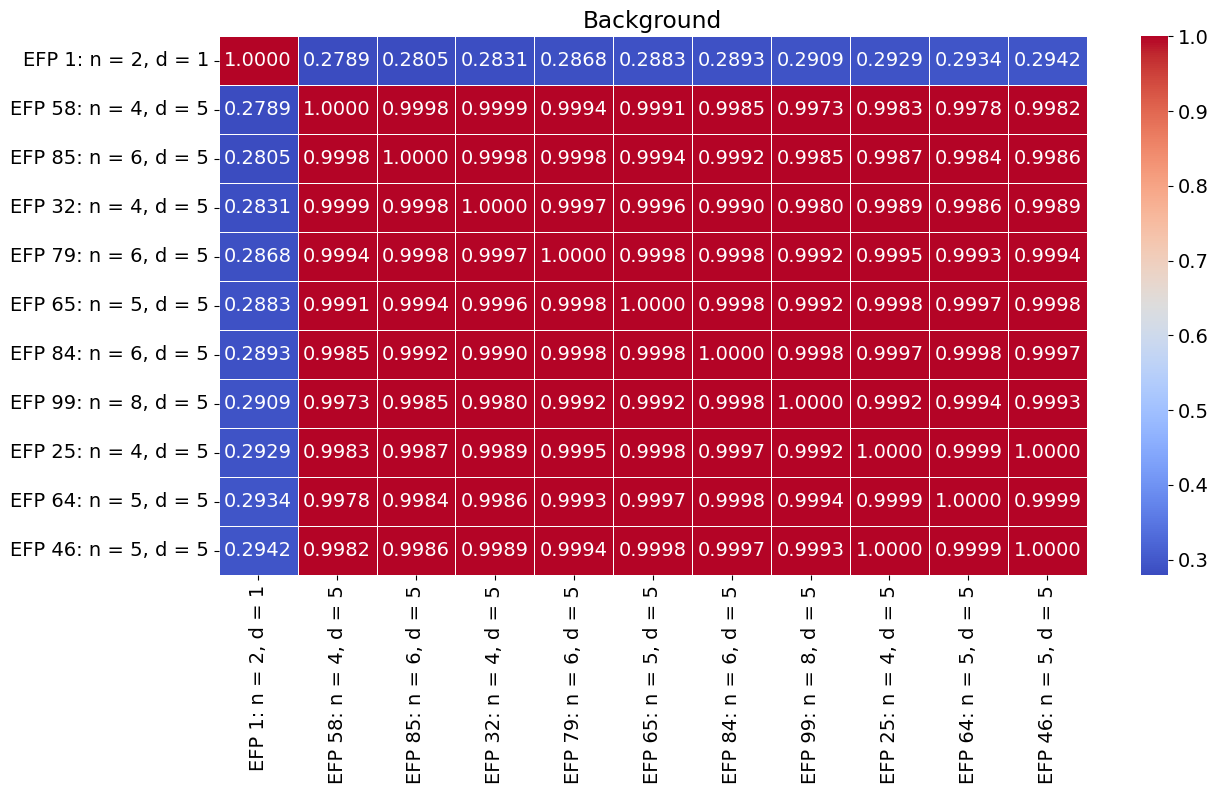

In [106]:
import seaborn as sns
plt.figure(figsize=(14,7))
sns.heatmap(corr_matrix_bkg, annot=True, cmap="coolwarm", fmt=".4f", linewidths=0.5)
plt.title("Background")
plt.show()

In [107]:
corr_matrix_sig = df_EFPs_sig.corr()
corr_matrix_sig

,"EFP 1: n = 2, d = 1","EFP 58: n = 4, d = 5","EFP 85: n = 6, d = 5","EFP 32: n = 4, d = 5","EFP 79: n = 6, d = 5","EFP 65: n = 5, d = 5","EFP 84: n = 6, d = 5","EFP 99: n = 8, d = 5","EFP 25: n = 4, d = 5","EFP 64: n = 5, d = 5","EFP 46: n = 5, d = 5"
"EFP 1: n = 2, d = 1",1.000000,0.334028,0.336077,0.334724,0.337255,0.338556,0.340004,0.341987,0.339702,0.341234,0.339657
"EFP 58: n = 4, d = 5",0.334028,1.000000,0.999910,0.999996,0.999850,0.999794,0.999528,0.999028,0.999695,0.999447,0.999712
"EFP 85: n = 6, d = 5",0.336077,0.999910,1.000000,0.999932,0.999988,0.999960,0.999842,0.999523,0.999911,0.999780,0.999922
"EFP 32: n = 4, d = 5",0.334724,0.999996,0.999932,1.000000,0.999887,0.999833,0.999589,0.999116,0.999743,0.999515,0.999764
"EFP 79: n = 6, d = 5",0.337255,0.999850,0.999988,0.999887,1.000000,0.999976,0.999898,0.999628,0.999944,0.999848,0.999962
"EFP 65: n = 5, d = 5",0.338556,0.999794,0.999960,0.999833,0.999976,1.000000,0.999938,0.999698,0.999990,0.999916,0.999989
"EFP 84: n = 6, d = 5",0.340004,0.999528,0.999842,0.999589,0.999898,0.999938,1.000000,0.999909,0.999966,0.999988,0.999964
"EFP 99: n = 8, d = 5",0.341987,0.999028,0.999523,0.999116,0.999628,0.999698,0.999909,1.000000,0.999778,0.999916,0.999769
"EFP 25: n = 4, d = 5",0.339702,0.999695,0.999911,0.999743,0.999944,0.999990,0.999966,0.999778,1.000000,0.999960,0.999993
"EFP 64: n = 5, d = 5",0.341234,0.999447,0.999780,0.999515,0.999848,0.999916,0.999988,0.999916,0.999960,1.000000,0.999953


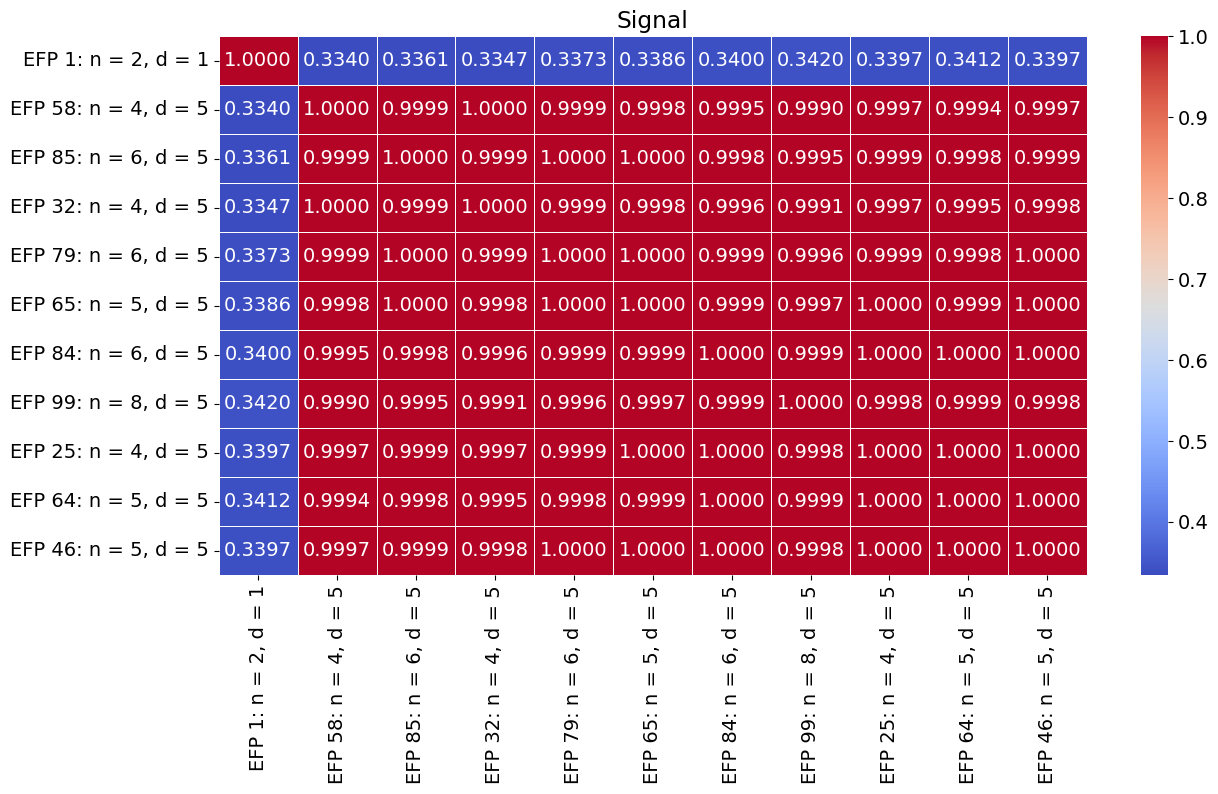

In [108]:
import seaborn as sns
plt.figure(figsize=(14,7))
sns.heatmap(corr_matrix_sig, annot=True, cmap="coolwarm", fmt=".4f", linewidths=0.5)
plt.title("Signal")
plt.show()

## 2 - ROC Curve

In [ ]:
# Plot roc curve using the histogram of each EFP
signal_idx = np.where(y == 1)[0]
bkg_idx    = np.where(y == 0)[0]
aucs = []

for i in range(X_EFP.shape[1]):
  EFP_bkg = X_EFP[bkg_idx,i]
  EFP_sig = X_EFP[signal_idx,i]
  scores = np.concatenate([EFP_bkg, EFP_sig])
  roc = roc_curve(y, scores)
  auc = roc_auc_score(y, scores)
  aucs.append(auc)

# Print five max values of auc and select corresponding EFP
max_aucs = np.sort(aucs)[-5:]
print(max_aucs)
max_efps = np.argsort(aucs)[-5:]
print(max_efps)

[0.89912171 0.89913301 0.89917181 0.899359   0.89948767]
[14 29 33 48 43]


In [ ]:
efpset = ef.EFPSet(('d<=', 5), measure='hadr',  beta=beta, verbose=True)
max_efps = np.array(max_efps)
print()
for i in max_efps:
  ind = int(i)
  graph = efpset.graphs(ind)
  n, _, d, v, _, c, p, _ = efpset.specs[ind]

  print("Graph:", graph)
  print("Number of vertices, n:", n)
  print("Number of edges,    d:", d)
  print("Maximum valency,    v:", v)
  print("VE complexity,      c:", c)
  print("Number of primes,   p:", p)
  print()

Originally Available EFPs:
  Prime: 23691
  Composite: 21540
  Total:  45231
Current Stored EFPs:
  Prime: 54
  Composite: 48
  Total:  102

Graph: [(0, 1), (0, 2), (1, 2), (1, 2), (1, 2)]
Number of vertices, n: 3
Number of edges,    d: 5
Maximum valency,    v: 4
VE complexity,      c: 3
Number of primes,   p: 1

Graph: [(0, 1), (0, 1), (0, 2), (1, 2), (0, 3)]
Number of vertices, n: 4
Number of edges,    d: 5
Maximum valency,    v: 4
VE complexity,      c: 3
Number of primes,   p: 1

Graph: [(0, 1), (0, 2), (1, 2), (0, 3), (1, 3)]
Number of vertices, n: 4
Number of edges,    d: 5
Maximum valency,    v: 3
VE complexity,      c: 3
Number of primes,   p: 1

Graph: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5)]
Number of vertices, n: 6
Number of edges,    d: 5
Maximum valency,    v: 5
VE complexity,      c: 2
Number of primes,   p: 1

Graph: [(0, 1), (0, 2), (1, 2), (0, 3), (0, 4)]
Number of vertices, n: 5
Number of edges,    d: 5
Maximum valency,    v: 4
VE complexity,      c: 3
Number of prime

In [ ]:
# Plot roc curve using the histogram of each EFP
efpset5 = ef.EFPSet(('d<=', 5), measure='hadr',  beta=beta)
efpset6 = ef.EFPSet(('d==', 6), measure='hadr',  beta=beta)
signal_idx = np.where(y == 1)[0]
bkg_idx    = np.where(y == 0)[0]
aucs = []
ns = []
ds = []
ps = []

for i in range(X_dim5.shape[1]):
  EFP_bkg = X_dim5[bkg_idx,i]
  EFP_sig = X_dim5[signal_idx,i]
  scores = np.concatenate([EFP_bkg, EFP_sig])
  roc = roc_curve(y, scores)
  auc = roc_auc_score(y, scores)
  if i < X_dim5.shape[1]:
    n, d = get_EFP(efpset5, i)
    p = is_EFP_prime(efpset5, i)
  else:
    n, d = get_EFP_d6(efpset6, i)
    p = is_EFP_prime6(efpset6, i)
  aucs.append(auc)
  ns.append(n)
  ds.append(d)
  ps.append(p)

df = pd.DataFrame({"AUC": aucs, "n": ns, "d": ds, "p":ps})
# sort df by auc
df = df.sort_values(by="AUC", ascending=False)

/usr/local/lib/python3.12/dist-packages/energyflow/efp.py:488: UserWarning: connected efp needed for [[2, 2, 0], [2, 4, 0]] not found
  warnings.warn('connected efp needed for {} not found'.format(formula))
/usr/local/lib/python3.12/dist-packages/energyflow/efp.py:488: UserWarning: connected efp needed for [[2, 1, 0], [2, 5, 0]] not found
  warnings.warn('connected efp needed for {} not found'.format(formula))
/usr/local/lib/python3.12/dist-packages/energyflow/efp.py:488: UserWarning: connected efp needed for [[2, 3, 0], [2, 3, 0]] not found
  warnings.warn('connected efp needed for {} not found'.format(formula))
/usr/local/lib/python3.12/dist-packages/energyflow/efp.py:488: UserWarning: connected efp needed for [[2, 3, 0], [3, 3, 0]] not found
  warnings.warn('connected efp needed for {} not found'.format(formula))
/usr/local/lib/python3.12/dist-packages/energyflow/efp.py:488: UserWarning: connected efp needed for [[2, 3, 0], [3, 3, 1]] not found
  warnings.warn('connected efp needed 

In [ ]:
df.head(10)

,AUC,n,d,p
43,0.899488,5,5,1
48,0.899359,6,5,1
33,0.899172,4,5,1
29,0.899133,4,5,1
14,0.899122,3,5,1
15,0.899064,3,5,1
28,0.898784,4,5,1
30,0.898765,4,5,1
13,0.898678,3,4,1
35,0.898633,5,5,1


In [ ]:
# retrieve 5 EFPs with largest AUC
index = [43,48,33,29,14,15,28,30,13,35]
EFPs = []
columns = []
for i in index:
  i = int(i)
  EFP = X_dim5[:,i]
  n, d = get_EFP(efpset5, i)
  EFPs.append(EFP)
  columns.append("EFP {}: n = {}, d = {}".format(i, n, d))
# create pandas DF with trnaspose EFPs
df_EFPs = pd.DataFrame(EFPs)
df_EFPs = df_EFPs.transpose()
df_EFPs.columns = columns

In [ ]:
df_EFPs

,"EFP 43: n = 5, d = 5","EFP 48: n = 6, d = 5","EFP 33: n = 4, d = 5","EFP 29: n = 4, d = 5","EFP 14: n = 3, d = 5","EFP 15: n = 3, d = 5","EFP 28: n = 4, d = 5","EFP 30: n = 4, d = 5","EFP 13: n = 3, d = 4","EFP 35: n = 5, d = 5"
0,1.520581e+07,2.620792e+07,1.218103e+07,2.011996e+07,3.264001e+07,2.401498e+07,1.840531e+07,2.216016e+07,6.624095e+05,3.728905e+07
1,5.999184e+06,9.922920e+06,4.875372e+06,7.923491e+06,1.295887e+07,9.324211e+06,7.560021e+06,9.113478e+06,3.125160e+05,1.504768e+07
2,2.671140e+07,4.050570e+07,2.208067e+07,3.567092e+07,5.739955e+07,4.308396e+07,3.298642e+07,3.871077e+07,1.060216e+06,5.858706e+07
3,1.352540e+07,2.354333e+07,1.043298e+07,1.897126e+07,3.137737e+07,2.377686e+07,1.693750e+07,2.044273e+07,6.356021e+05,3.506964e+07
4,1.252878e+07,2.305575e+07,9.782832e+06,1.693401e+07,2.766014e+07,2.130331e+07,1.432291e+07,1.688520e+07,5.590882e+05,2.973920e+07
...,...,...,...,...,...,...,...,...,...,...
199995,1.316296e+09,4.173108e+09,8.293234e+08,1.820667e+09,3.066724e+09,2.235401e+09,1.387808e+09,1.928534e+09,2.300195e+07,5.521054e+09
199996,5.187064e+07,8.620072e+07,4.146017e+07,7.033143e+07,1.138932e+08,8.780912e+07,6.276920e+07,7.358957e+07,1.802511e+06,1.192518e+08
199997,7.473931e+06,1.274442e+07,6.023297e+06,9.798805e+06,1.578100e+07,1.184422e+07,8.960486e+06,1.056874e+07,3.687902e+05,1.751844e+07
199998,1.184833e+08,2.314989e+08,8.971967e+07,1.574939e+08,2.543366e+08,1.928561e+08,1.398591e+08,1.704198e+08,3.406283e+06,3.189330e+08


In [ ]:
corr_matrix = df_EFPs.corr()
corr_matrix

,"EFP 43: n = 5, d = 5","EFP 48: n = 6, d = 5","EFP 33: n = 4, d = 5","EFP 29: n = 4, d = 5","EFP 14: n = 3, d = 5","EFP 15: n = 3, d = 5","EFP 28: n = 4, d = 5","EFP 30: n = 4, d = 5","EFP 13: n = 3, d = 4","EFP 35: n = 5, d = 5"
"EFP 43: n = 5, d = 5",1.000000,0.966891,0.999791,0.999809,0.999426,0.999273,0.999963,0.999937,0.977711,0.959331
"EFP 48: n = 6, d = 5",0.966891,1.000000,0.962956,0.963133,0.958480,0.961207,0.967089,0.968094,0.917837,0.999543
"EFP 33: n = 4, d = 5",0.999791,0.962956,1.000000,0.999673,0.999655,0.999003,0.999648,0.999634,0.979433,0.954969
"EFP 29: n = 4, d = 5",0.999809,0.963133,0.999673,1.000000,0.999743,0.999776,0.999801,0.999633,0.979596,0.955237
"EFP 14: n = 3, d = 5",0.999426,0.958480,0.999655,0.999743,1.000000,0.999375,0.999343,0.999242,0.981364,0.950074
"EFP 15: n = 3, d = 5",0.999273,0.961207,0.999003,0.999776,0.999375,1.000000,0.999370,0.998964,0.980134,0.953194
"EFP 28: n = 4, d = 5",0.999963,0.967089,0.999648,0.999801,0.999343,0.999370,1.000000,0.999918,0.977195,0.959580
"EFP 30: n = 4, d = 5",0.999937,0.968094,0.999634,0.999633,0.999242,0.998964,0.999918,1.000000,0.976455,0.960701
"EFP 13: n = 3, d = 4",0.977711,0.917837,0.979433,0.979596,0.981364,0.980134,0.977195,0.976455,1.000000,0.907023
"EFP 35: n = 5, d = 5",0.959331,0.999543,0.954969,0.955237,0.950074,0.953194,0.959580,0.960701,0.907023,1.000000


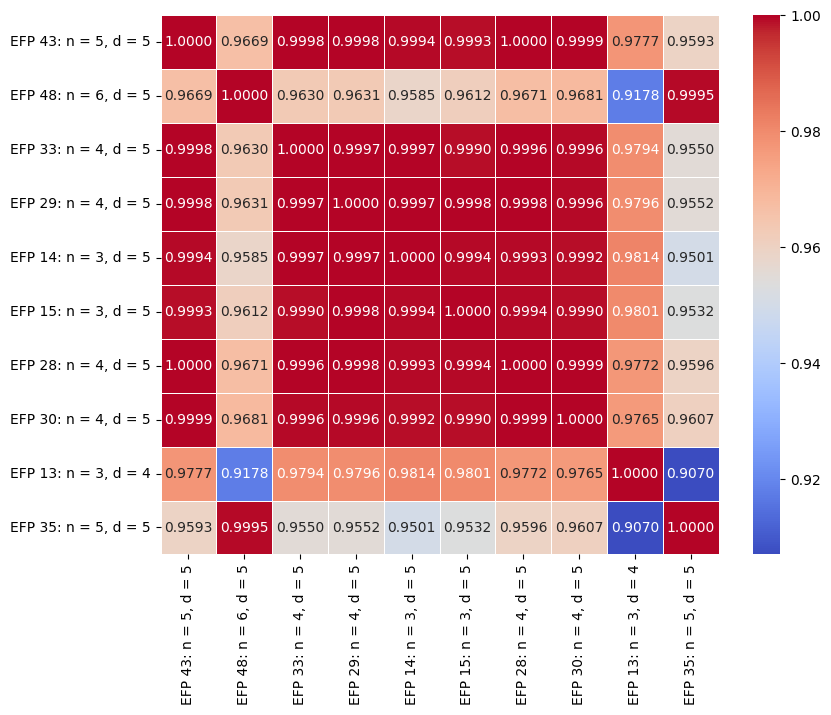

In [ ]:
import seaborn as sns
plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".4f", linewidths=0.5)
plt.show()

In [ ]:
get_EFP(efpset5, 43)

(np.int64(5), np.int64(5))

In [ ]:
aucs = np.array(aucs)
aucs_sort = np.sort(aucs)
print(aucs_sort)

[0.36168476 0.3619712  0.36253385 0.36256601 0.36258625 0.36265577
 0.36319168 0.36324422 0.3635076  0.36359446 0.3637949  0.36387811
 0.36396426 0.36396747 0.36411075 0.3641509  0.36418725 0.36421617
 0.3644408  0.36452418 0.36458384 0.36489565 0.36514913 0.36533122
 0.36533498 0.36543395 0.36544935 0.36545237 0.36562808 0.36579567
 0.3661973  0.36639076 0.36644699 0.36644722 0.36652103 0.36655823
 0.36666858 0.3668379  0.36687641 0.36693256 0.36707988 0.36715748
 0.36719177 0.36762614 0.36818657 0.36840049 0.36852299 0.36922958
 0.36924542 0.36926901 0.369594   0.36984012 0.37007913 0.37034672
 0.37076001 0.37085897 0.37107696 0.37110383 0.3712521  0.3717946
 0.37185317 0.37195695 0.37199423 0.37214672 0.37220775 0.3725418
 0.37300868 0.3734359  0.37368242 0.37368704 0.37387506 0.37396583
 0.3740553  0.37432398 0.37469997 0.37542989 0.37614054 0.37624718
 0.37644125 0.37689326 0.37700582 0.3771176  0.37715263 0.37753711
 0.3779881  0.37829899 0.37835953 0.37877004 0.37933783 0.379388

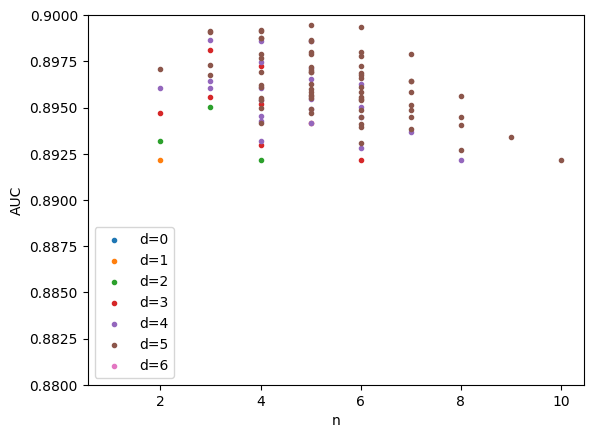

In [ ]:
# group by n
df_d_grouped = df.groupby("d")
# plot auc as a function of d for each group
for name, group in df_d_grouped:
  plt.scatter(group["n"], group["AUC"], label=f"d={name}", marker='.')

plt.xlabel("n")
plt.ylabel("AUC")
plt.ylim(0.88,0.9)
plt.legend()
plt.show()

In [ ]:
df_d_grouped.get_group(3)

,AUC,n,d,p
12,0.898091,3,3,1
16,0.897233,4,3,1
7,0.895594,3,3,1
20,0.895179,4,3,1
3,0.894702,2,3,1
60,0.894150,5,3,2
55,0.892973,4,3,2
70,0.892142,6,3,3


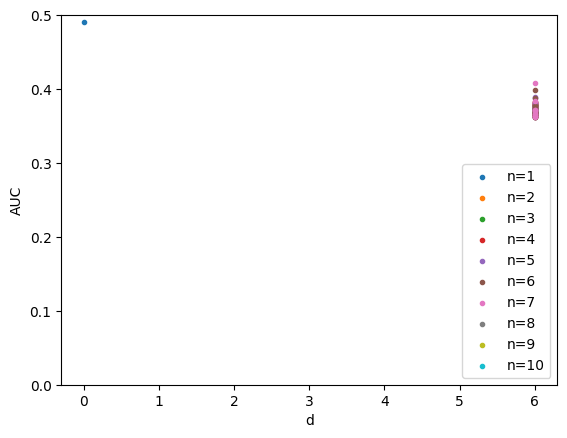

In [ ]:
# group by n
df_n_grouped = df.groupby("n")

for name, group in df_n_grouped:
  plt.scatter(group["d"], group["AUC"], label=f"n={name}", marker='.')

plt.xlabel("d")
plt.ylabel("AUC")
plt.ylim(0,0.5)
plt.legend(loc='lower right')
plt.show()

In [ ]:
aucs_sort = np.sort(aucs)
print(aucs_sort)

[0.36168476 0.3619712  0.36253385 0.36256601 0.36258625 0.36265577
 0.36319168 0.36324422 0.3635076  0.36359446 0.3637949  0.36387811
 0.36396426 0.36396747 0.36411075 0.3641509  0.36418725 0.36421617
 0.3644408  0.36452418 0.36458384 0.36489565 0.36514913 0.36533122
 0.36533498 0.36543395 0.36544935 0.36545237 0.36562808 0.36579567
 0.3661973  0.36639076 0.36644699 0.36644722 0.36652103 0.36655823
 0.36666858 0.3668379  0.36687641 0.36693256 0.36707988 0.36715748
 0.36719177 0.36762614 0.36818657 0.36840049 0.36852299 0.36922958
 0.36924542 0.36926901 0.369594   0.36984012 0.37007913 0.37034672
 0.37076001 0.37085897 0.37107696 0.37110383 0.3712521  0.3717946
 0.37185317 0.37195695 0.37199423 0.37214672 0.37220775 0.3725418
 0.37300868 0.3734359  0.37368242 0.37368704 0.37387506 0.37396583
 0.3740553  0.37432398 0.37469997 0.37542989 0.37614054 0.37624718
 0.37644125 0.37689326 0.37700582 0.3771176  0.37715263 0.37753711
 0.3779881  0.37829899 0.37835953 0.37877004 0.37933783 0.379388

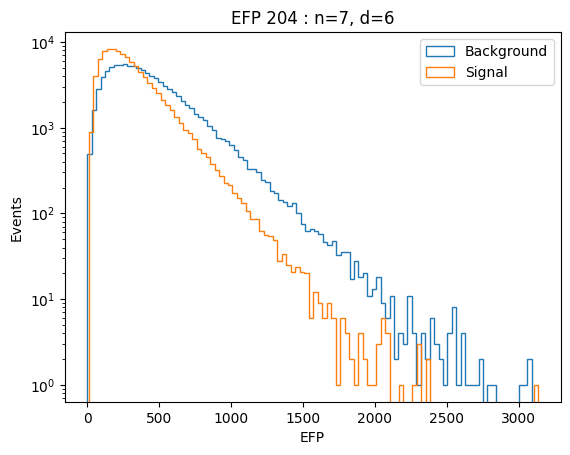

In [ ]:
# plot histogram of the efp
i = 204
EFP_bkg = X_EFP[bkg_idx,i]
EFP_sig = X_EFP[signal_idx,i]
n, d = get_EFP_d6(efpset6, i)
plt.hist(EFP_bkg, bins=100, histtype='step', label='Background')
plt.hist(EFP_sig, bins=100, histtype='step',label='Signal')
plt.title('EFP {} : n={}, d={}'.format(i, n, d))
plt.xlabel('EFP')
plt.ylabel('Events')
#plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

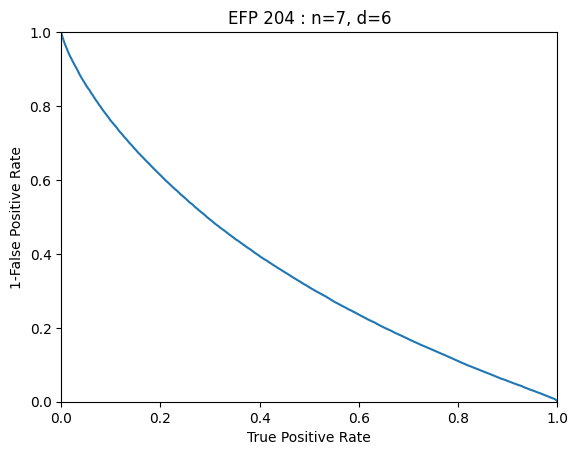


AUC: 0.3616847594



In [ ]:
# Plot roc curve using the histogram of each EFP
signal_idx = np.where(y == 1)[0]
bkg_idx    = np.where(y == 0)[0]
i = 204
n, d = get_EFP_d6(efpset6, i)
EFP_bkg = X_EFP[bkg_idx,i]
EFP_sig = X_EFP[signal_idx,i]
scores = np.concatenate([EFP_bkg, EFP_sig])

roc = roc_curve(y, scores)
plt.plot(roc[1], 1-roc[0], '-')
plt.xlabel('True Positive Rate')
plt.ylabel('1-False Positive Rate')
plt.title('EFP {} : n={}, d={}'.format(i, n, d))
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

# Print AUC
auc = roc_auc_score(y, scores)
print()
print('AUC:'.format(auc), auc)
print()

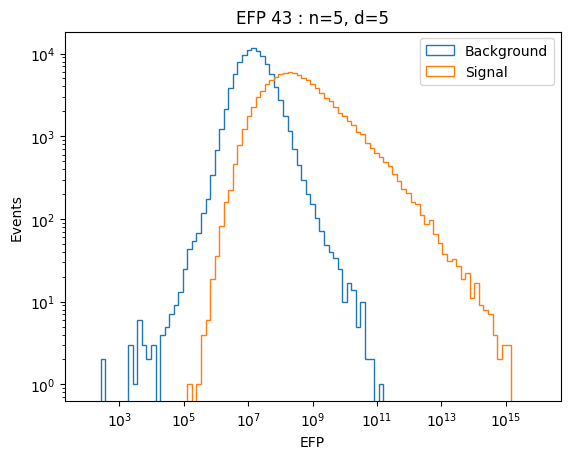

In [ ]:
# plot histogram of the efp
i = 43
EFP_bkg = X_EFP[bkg_idx,i]
EFP_sig = X_EFP[signal_idx,i]
n, d = get_EFP(efpset5, i)
plt.hist(EFP_bkg, bins=np.logspace(2,16,100), histtype='step', label='Background')
plt.hist(EFP_sig, bins=np.logspace(2,16,100), histtype='step',label='Signal')
plt.title('EFP {} : n={}, d={}'.format(i, n, d))
plt.xlabel('EFP')
plt.ylabel('Events')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

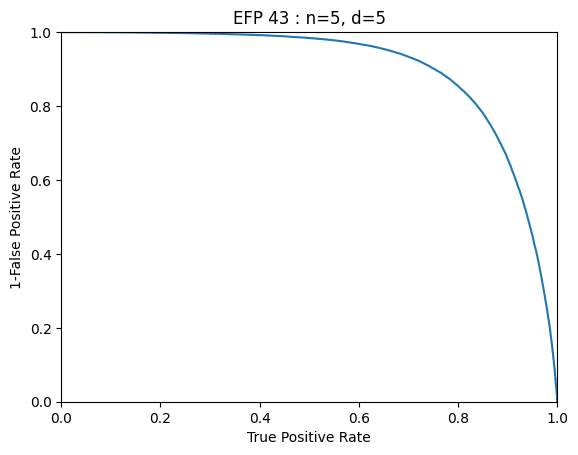


AUC: 0.8994876747



In [ ]:
# Plot roc curve using the histogram of each EFP
signal_idx = np.where(y == 1)[0]
bkg_idx    = np.where(y == 0)[0]
i = 43
EFP_bkg = X_EFP[bkg_idx,i]
EFP_sig = X_EFP[signal_idx,i]
n, d = get_EFP(efpset5, i)
scores = np.concatenate([EFP_bkg, EFP_sig])

roc = roc_curve(y, scores)
plt.plot(roc[1], 1-roc[0], '-')
plt.xlabel('True Positive Rate')
plt.ylabel('1-False Positive Rate')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title('EFP {} : n={}, d={}'.format(i, n, d))
plt.show()

# Print AUC
auc = roc_auc_score(y, scores)
print()
print('AUC:'.format(auc), auc)
print()

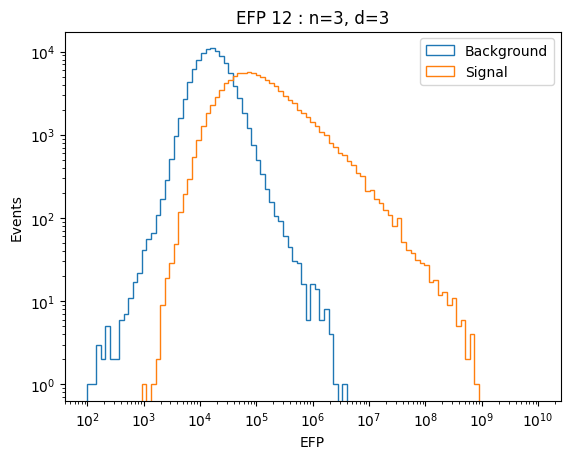

In [ ]:
# plot histogram of the efp
i = 12
EFP_bkg = X_EFP[bkg_idx,i]
EFP_sig = X_EFP[signal_idx,i]
n, d = get_EFP(efpset5, i)
plt.hist(EFP_bkg, bins=np.logspace(2,10,100), histtype='step', label='Background')
plt.hist(EFP_sig, bins=np.logspace(2,10,100), histtype='step',label='Signal')
plt.title('EFP {} : n={}, d={}'.format(i, n, d))
plt.xlabel('EFP')
plt.ylabel('Events')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

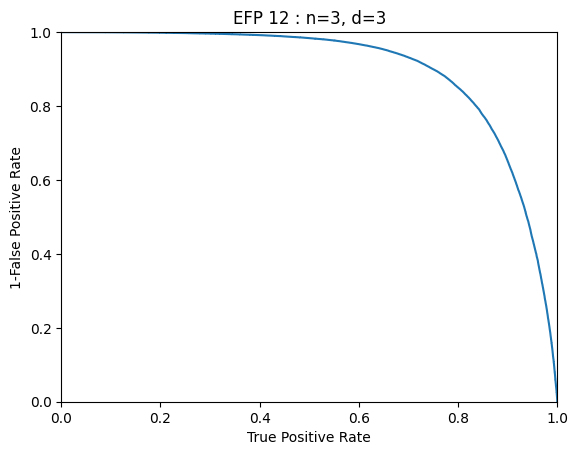


AUC: 0.8980908151



In [ ]:
# Plot roc curve using the histogram of each EFP
signal_idx = np.where(y == 1)[0]
bkg_idx    = np.where(y == 0)[0]
i = 12
EFP_bkg = X_EFP[bkg_idx,i]
EFP_sig = X_EFP[signal_idx,i]
n, d = get_EFP(efpset5, i)
scores = np.concatenate([EFP_bkg, EFP_sig])

roc = roc_curve(y, scores)
plt.plot(roc[1], 1-roc[0], '-')
plt.xlabel('True Positive Rate')
plt.ylabel('1-False Positive Rate')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title('EFP {} : n={}, d={}'.format(i, n, d))
plt.show()

# Print AUC
auc = roc_auc_score(y, scores)
print()
print('AUC:'.format(auc), auc)
print()

## 3 - Turn-on curve

In [ ]:
pt4_offline = np.load('pt4_offline.npy')
pt4_sig_offline = pt4_offline[signal_idx]
pt4_bkg_offline = pt4_offline[bkg_idx]

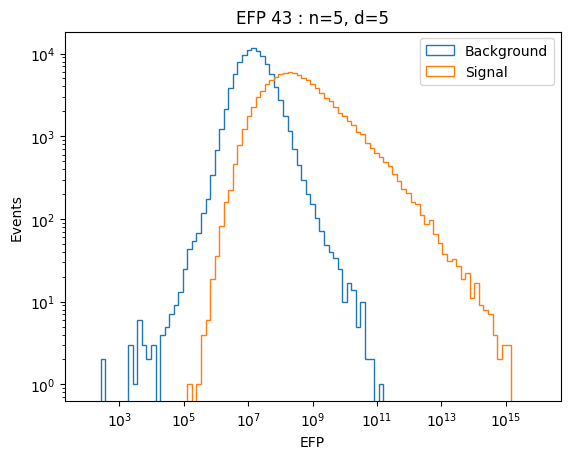

In [ ]:
# plot histogram of the efp
i = 43
EFP_bkg = X_EFP[bkg_idx,i]
EFP_sig = X_EFP[signal_idx,i]
n, d = get_EFP(efpset5, i)
plt.hist(EFP_bkg, bins=np.logspace(2,16,100), histtype='step', label='Background')
plt.hist(EFP_sig, bins=np.logspace(2,16,100), histtype='step',label='Signal')
plt.title('EFP {} : n={}, d={}'.format(i, n, d))
plt.xlabel('EFP')
plt.ylabel('Events')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

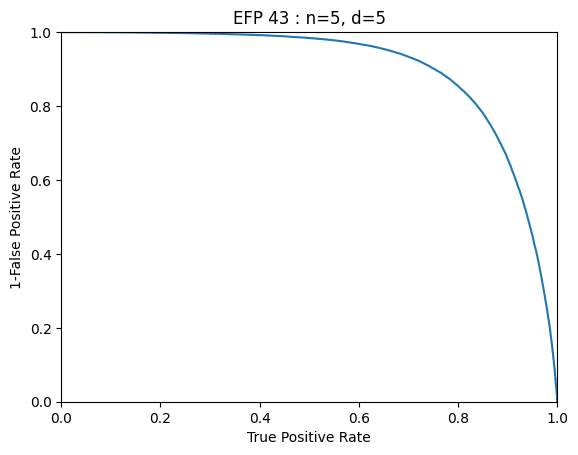


AUC: 0.8994876747



In [ ]:
# Plot roc curve using the histogram of each EFP
signal_idx = np.where(y == 1)[0]
bkg_idx    = np.where(y == 0)[0]
i = 43
EFP_bkg = X_EFP[bkg_idx,i]
EFP_sig = X_EFP[signal_idx,i]
n, d = get_EFP(efpset5, i)
scores = np.concatenate([EFP_bkg, EFP_sig])

roc = roc_curve(y, scores)
plt.plot(roc[1], 1-roc[0], '-')
plt.xlabel('True Positive Rate')
plt.ylabel('1-False Positive Rate')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title('EFP {} : n={}, d={}'.format(i, n, d))
plt.show()

# Print AUC
auc = roc_auc_score(y, scores)
print()
print('AUC:'.format(auc), auc)
print()

In [ ]:
# Select energy threshold for 5% background acceptance
# Define histogram for bkg ET4(offline)
bins = np.logspace(2,16,100)
counts, edges = np.histogram(EFP_bkg, bins = bins)
# Calculate histogram integral
total_integral = np.sum(counts)
# Calculate the bkg efficiency for each threshold
thresholds = []
background_efficiency = []
bkg_counts = 0
for i in range(len(counts)):
  bkg_counts += counts[i]
  if total_integral != 0:
    bkg_acceptance = bkg_counts/total_integral
    background_efficiency.append(bkg_acceptance)
    cut = edges[i+1]
    thresholds.append(cut)
    if bkg_acceptance >= 0.95:
      threshold = cut
      break
print(f'The 5% acceptance threshold is: {threshold:.4f}')

The 5% acceptance threshold is: 166810053.7200


In [ ]:
tot_sig_energies = []
sel_sig_energies = []

for i in range(len(EFP_sig)):
  if pt4_sig_offline[i] != 0:
    tot_sig_energies.append(pt4_sig_offline[i])
    if EFP_sig[i] >= threshold:
      sel_sig_energies.append(pt4_sig_offline[i])

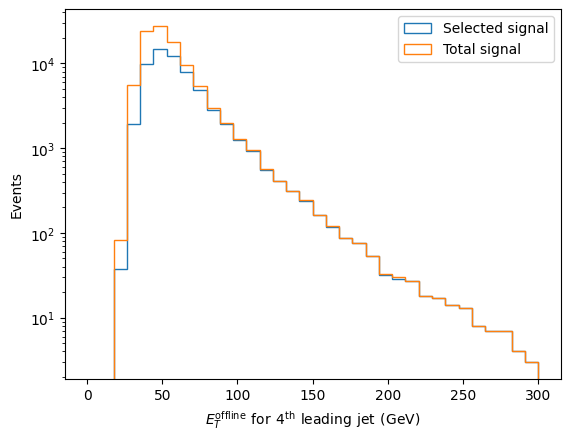

In [ ]:
# Plot distribution of the energy of the fourth leading jet for the selected signal and for all signal events
plt.hist(sel_sig_energies, bins=np.linspace(0.01,300,35), histtype='step', label='Selected signal')
plt.hist(tot_sig_energies, bins=np.linspace(0.01,300,35), histtype='step',label='Total signal')
plt.xlabel(r'$E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('Events')
plt.yscale('log')
#plt.xlim(0,320)
plt.legend()
plt.show()

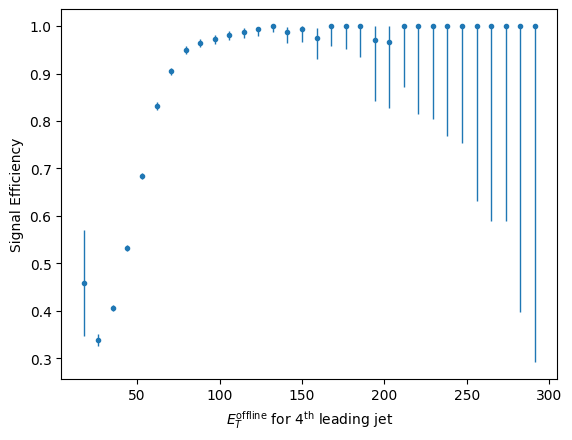

In [ ]:
# Define histograms of the energies
bins=np.linspace(0.01,300,35)
selected_counts, edges = np.histogram(sel_sig_energies, bins=bins)
signal_counts, edges1 = np.histogram(tot_sig_energies, bins=bins)
# Define arrays to store the signal efficiency and jet energy
signal_efficiency = []
energy = []
sel_sig_counts = []
sig_counts = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts[i]
  if sig_i != 0:
    sig_counts.append(sig_i)
    sel_sig_counts.append(sel_sig_i)
    signal_efficiency.append(sel_sig_i/sig_i)
    energy.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low, ci_upp = proportion_confint(sel_sig_counts, sig_counts, alpha=0.05, method='beta')
# Compute error bars
err_low = signal_efficiency - ci_low
err_upp = ci_upp - signal_efficiency
# Plot signal efficiency as a function of the energy
plt.errorbar(energy, signal_efficiency, yerr=[err_low, err_upp], fmt='.', elinewidth=1)
plt.xlabel(r'$E_{T}^{\mathrm{offline}}$ for $4^{\mathrm{th}}$ leading jet')
plt.ylabel('Signal Efficiency')
plt.show()

In [ ]:
np.savez('EFP43_pt4_offline.npz', energy=energy, signal_eff=signal_efficiency, err_low=err_low, err_upp=err_upp)

### Invariant mass of the bbbb system

In [ ]:
# Retrieve pT of the fourth leading jet for all signal events
signal_mass = []
selected_mass = []
for i in range(len(true_mass_sig)):
  if true_mass_sig[i] != 0:
    signal_mass.append(true_mass_sig[i])
    if EFP_sig[i] >= threshold:
      selected_mass.append(true_mass_sig[i])

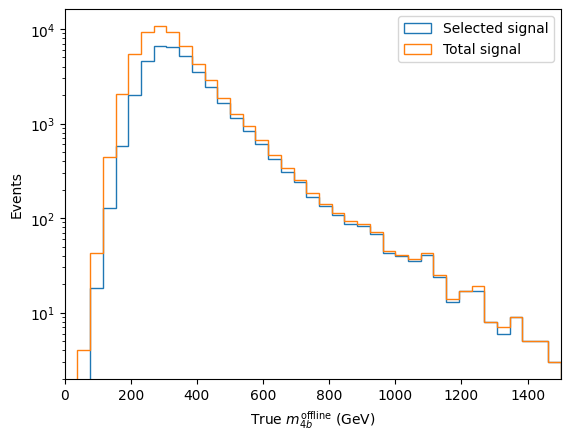

In [ ]:
# Plot distribution of the invariant mass for the selected signal and for all signal events
plt.hist(selected_mass, bins=np.linspace(0.1,1500,40), histtype='step', label='Selected signal')
plt.hist(signal_mass, bins=np.linspace(0.1,1500,40), histtype='step',label='Total signal')
plt.xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
plt.ylabel('Events')
plt.yscale('log')
plt.xlim(0,1500)
plt.legend()
plt.show()

In [ ]:
# Define histograms of the energies
bins=np.linspace(0.1,1500,40)
selected_counts, edges = np.histogram(selected_mass, bins=bins)
signal_counts, edges1 = np.histogram(signal_mass, bins=bins)
# Define arrays to store the signal efficiency and invariant mass
signal_efficiency = []
mass = []
sel_sig_counts = []
sig_counts = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts[i]
  if sig_i != 0:
    sig_counts.append(sig_i)
    sel_sig_counts.append(sel_sig_i)
    signal_efficiency.append(sel_sig_i/sig_i)
    mass.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low, ci_upp = proportion_confint(sel_sig_counts, sig_counts, alpha=0.05, method='beta')
# Compute error bars
err_low = signal_efficiency - ci_low
err_upp = ci_upp - signal_efficiency


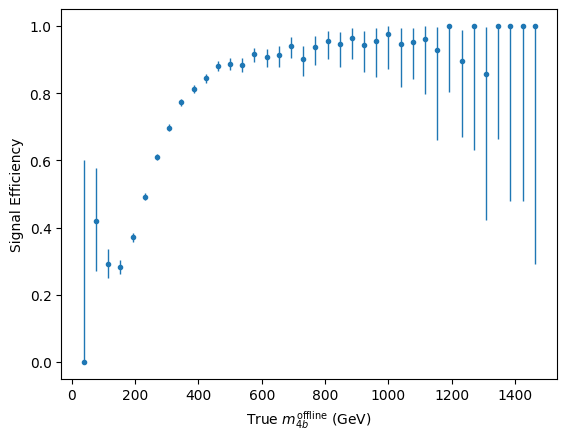

In [ ]:
# Plot signal efficiency as a function of the invariant mass
plt.errorbar(mass, signal_efficiency, yerr=[err_low, err_upp], fmt='.', elinewidth=1)
plt.xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
plt.ylabel('Signal Efficiency')
plt.show()

In [ ]:
np.savez('EFP43_mass_offline.npz', energy=mass, signal_eff=signal_efficiency, err_low=err_low, err_upp=err_upp)

# IX - Linear Classifier

In this section, we apply a linear classifier (Linear Discriminant Analysis) to distinguish signal and background using supervised learning.

## 1 - Test different dmax


EFPs d <= 1 AUC: 0.8892416442858242


EFPs d <= 2 AUC: 0.8883678395764094


EFPs d <= 3 AUC: 0.924982449808946


EFPs d <= 4 AUC: 0.9300867745786667


EFPs d <= 5 AUC: 0.9313522145576442


EFPs d <= 6 AUC: 0.9443176369271123



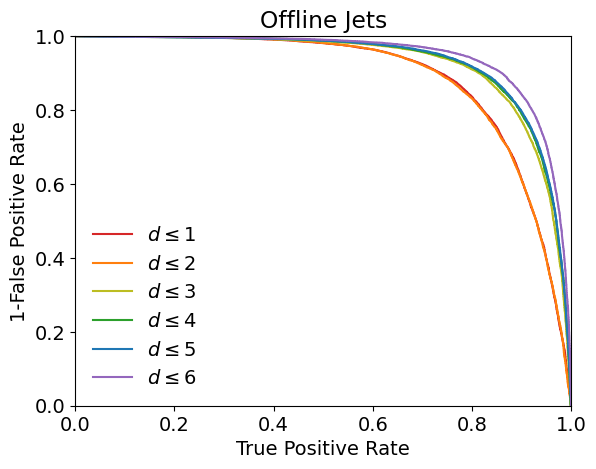

In [ ]:
# Train models with different numbers of EFPs as input
dmax = 5
rocs = []
aucs = []
for d in range(1, dmax+1):

    # build architecture
    model =LinearDiscriminantAnalysis(tol=1e-12)

    # select EFPs with degree <= d
    X_d = X_dim5[:,efpset.sel(('d<=', d))]

    # Split into training and test sets
    (X_train, X_test, y_train, y_test) = train_test_split(X_d, y, test_size=test_frac)

    # Standardize data
    scaler = StandardScaler()
    X_train_nor = scaler.fit_transform(X_train)
    X_test_nor = scaler.transform(X_test)

    # train model
    model.fit(X_train_nor, y_train)

    # get predictions on test data
    preds = model.predict_proba(X_test_nor)

    # get ROC curve if we have sklearn
    if roc_curve:
        rocs.append(roc_curve(y_test, preds[:,1]))

        # get area under the ROC curve
        auc = roc_auc_score(y_test, preds[:,1])
        aucs.append(auc)
        print()
        print('EFPs d <= {} AUC:'.format(d), auc)
        print()

# Repeat for d <= 6
model =LinearDiscriminantAnalysis(tol=1e-12)
# Split into training and test sets
(X_train, X_test, y_train, y_test) = train_test_split(X_EFP, y, test_size=test_frac)

# Standardize data
scaler = StandardScaler()
X_train_nor = scaler.fit_transform(X_train)
X_test_nor = scaler.transform(X_test)

# train model
model.fit(X_train_nor, y_train)

# get predictions on test data
preds = model.predict_proba(X_test_nor)

# get ROC curve if we have sklearn
if roc_curve:
    rocs.append(roc_curve(y_test, preds[:,1]))
    # get area under the ROC curve
    auc = roc_auc_score(y_test, preds[:,1])
    aucs.append(auc)
    print()
    print('EFPs d <= 6 AUC:'.format(d), auc)
    print()

# iterate over the ROC curves and plot them
for i,d in enumerate(range(1, dmax+2)):
    plt.plot(rocs[i][1], 1-rocs[i][0], '-', color=colors[i],
                                            label=r'$d \leq${}'.format(d))

# axes labels
plt.xlabel('True Positive Rate')
plt.ylabel('1-False Positive Rate')
plt.title('Offline Jets')
# axes limits
plt.xlim(0, 1)
plt.ylim(0, 1)

# make legend and show plot
plt.legend(loc='lower left', frameon=False)
plt.show()

## 2 - Turn-on Curve

In this section, the inputs of the classifier are all the EFPs with d<=6 (205 EFPs per event).

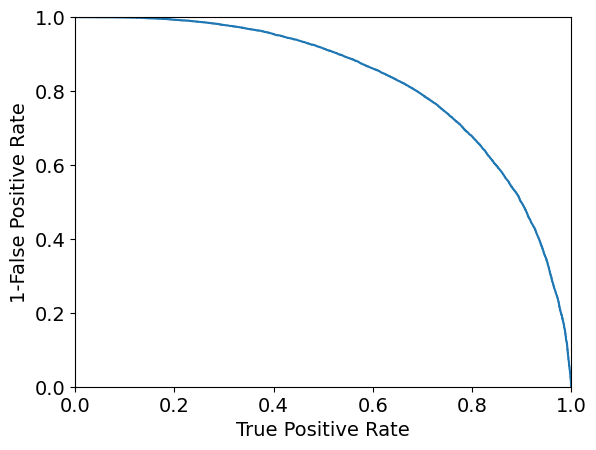


AUC: 0.825614175



In [160]:
# Define model
linear_model = LinearDiscriminantAnalysis(tol=1e-12)

# Split into training and test sets
test_frac = 0.2
signal_idx = np.where(y == 1)[0]
bkg_idx    = np.where(y == 0)[0]

X_sig_train, X_sig_test, pt4_sig_train, pt4_sig_test, mass_sig_train, mass_sig_test, y_sig_train, y_sig_test = train_test_split(
    X_EFP[signal_idx], pt4_offline[signal_idx], true_mass_offline[signal_idx], y[signal_idx], test_size=test_frac, random_state=42
)

X_bkg_train, X_bkg_test, pt4_bkg_train, pt4_bkg_test,  mass_bkg_train, mass_bkg_test, y_bkg_train, y_bkg_test = train_test_split(
    X_EFP[bkg_idx], pt4_offline[bkg_idx], true_mass_offline[bkg_idx], y[bkg_idx], test_size=test_frac, random_state=42
)

X_train = np.concatenate([X_sig_train, X_bkg_train])
y_train = np.concatenate([y_sig_train, y_bkg_train])

X_test  = np.concatenate([X_sig_test,  X_bkg_test])
y_test  = np.concatenate([y_sig_test,  y_bkg_test])
pt4_test = np.concatenate([pt4_sig_test, pt4_bkg_test])
mass_test = np.concatenate([mass_sig_test, mass_bkg_test])

# Standardize data
scaler = StandardScaler()
X_train_nor = scaler.fit_transform(X_train)
X_test_nor = scaler.transform(X_test)

# Train model
linear_model.fit(X_train_nor, y_train)

# Get predictions on the test set
preds = linear_model.predict_proba(X_test_nor)

# Plot ROC curve
roc = roc_curve(y_test, preds[:,1])
plt.plot(roc[1], 1-roc[0], '-')
plt.xlabel('True Positive Rate')
plt.ylabel('1-False Positive Rate')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

# Print AUC
auc = roc_auc_score(y_test, preds[:,1])
print()
print('AUC:'.format(auc), auc)
print()

In [161]:
# Divide test set into signal and background events and retrieve corresponding scores
preds_bkg = preds[y_test == 0][:,1]
preds_sig = preds[y_test == 1][:,1]

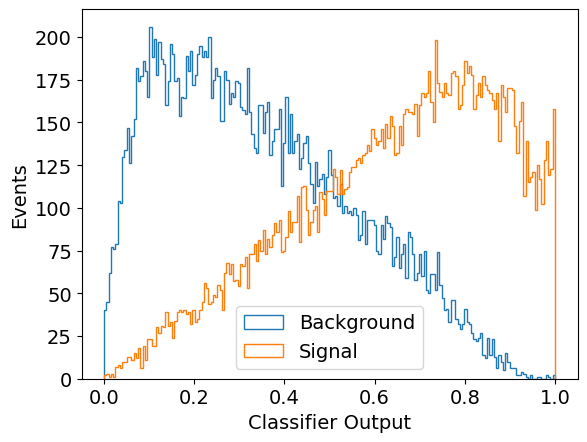

In [162]:
# Plot classifier output
plot_scores(preds_bkg, preds_sig)

In [163]:
# Compute the 5% background aceptance threshold
cut = get_threshold(preds_bkg)
print(f'The 5% acceptance threshold is: {cut:.4f}')

The 5% acceptance threshold is: 0.7327


### Energy of the fourth-leading jet

In [164]:
# Retrieve pT of the fourth leading jet for all signal events
signal_energies = []
selected_energies = []
for i in range(len(X_test)):
  if y_test[i] == 1:
    if pt4_test[i] != 0:
      signal_energies.append(pt4_test[i])
      if preds[i][1] >= cut:
        selected_energies.append(pt4_test[i])

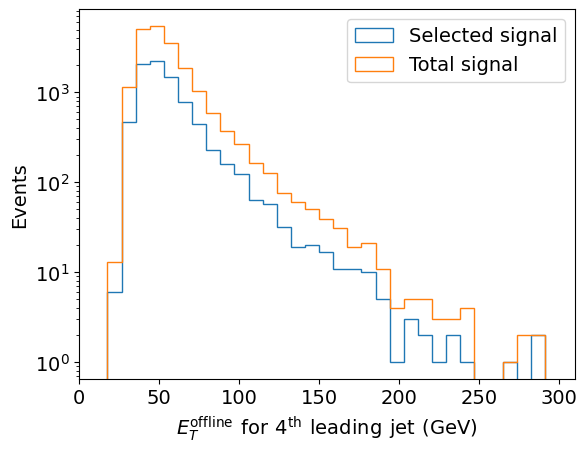

In [165]:
# Plot distribution of the energy of the fourth leading jet for the selected signal and for all signal events
plt.hist(selected_energies, bins=np.linspace(0.1,300,35), histtype='step', label='Selected signal')
plt.hist(signal_energies, bins=np.linspace(0.1,300,35), histtype='step',label='Total signal')
plt.xlabel(r'$E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('Events')
plt.yscale('log')
plt.xlim(0,310)
plt.legend()
plt.show()

In [166]:
bins=np.linspace(0.1,300,35)
selected_counts_lda, edges = np.histogram(selected_energies, bins=bins)
signal_counts, edges1 = np.histogram(signal_energies, bins=bins)
# Define arrays to store the signal efficiency and jet energy
signal_efficiency_lda = []
energy_lda = []
sel_sig_counts_lda = []
sig_counts_lda = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts_lda)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts_lda[i]
  if sig_i != 0:
    sig_counts_lda.append(sig_i)
    sel_sig_counts_lda.append(sel_sig_i)
    signal_efficiency_lda.append(sel_sig_i/sig_i)
    energy_lda.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low_lda, ci_upp_lda = proportion_confint(sel_sig_counts_lda, sig_counts_lda, alpha=0.05, method='beta')
# Compute error bars
err_low_lda = signal_efficiency_lda - ci_low_lda
err_upp_lda = ci_upp_lda - signal_efficiency_lda

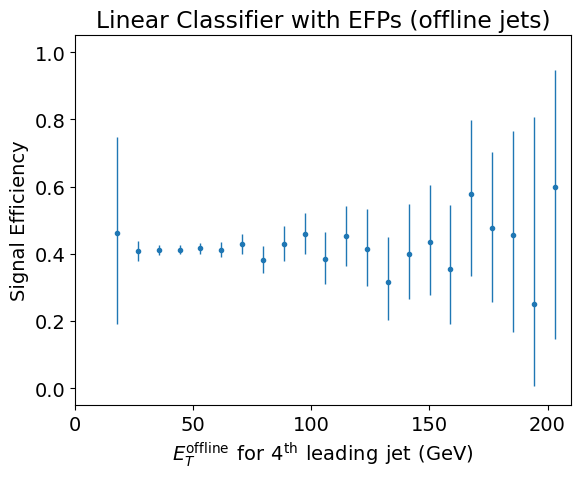

In [167]:
# Plot signal efficiency as a function of the energy
plt.errorbar(energy_lda, signal_efficiency_lda, yerr=[err_low_lda, err_upp_lda], fmt='.', elinewidth=1)
plt.xlabel(r'$E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('Signal Efficiency')
plt.title('Linear Classifier with EFPs (offline jets)')
plt.xlim(0,210)

plt.show()

In [ ]:
np.savez('offline_jets_lda_pt4.npz', energy=energy_lda, signal_eff=signal_efficiency_lda, err_low=err_low_lda, err_upp=err_upp_lda)

### Invariant mass of the bbbb system

In [140]:
# Retrieve pT of the fourth leading jet for all signal events
signal_mass = []
selected_mass = []
for i in range(len(X_test)):
  if y_test[i] == 1:
    if mass_test[i] != 0:
      signal_mass.append(mass_test[i])
      if preds[i][1] >= cut:
        selected_mass.append(mass_test[i])

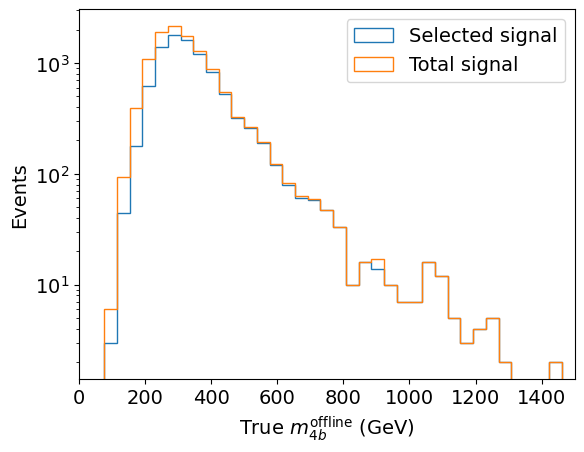

In [141]:
# Plot distribution of the invariant mass for the selected signal and for all signal events
plt.hist(selected_mass, bins=np.linspace(0.1,1500,40), histtype='step', label='Selected signal')
plt.hist(signal_mass, bins=np.linspace(0.1,1500,40), histtype='step',label='Total signal')
plt.xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
plt.ylabel('Events')
plt.yscale('log')
plt.xlim(0,1500)
plt.legend()
plt.show()

In [142]:
# Define histograms of the energies
bins=np.linspace(0.1,1500,40)
selected_counts, edges = np.histogram(selected_mass, bins=bins)
signal_counts, edges1 = np.histogram(signal_mass, bins=bins)
# Define arrays to store the signal efficiency and invariant mass
signal_efficiency = []
mass = []
sel_sig_counts = []
sig_counts = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts[i]
  if sig_i != 0:
    sig_counts.append(sig_i)
    sel_sig_counts.append(sel_sig_i)
    signal_efficiency.append(sel_sig_i/sig_i)
    mass.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low, ci_upp = proportion_confint(sel_sig_counts, sig_counts, alpha=0.05, method='beta')
# Compute error bars
err_low = signal_efficiency - ci_low
err_upp = ci_upp - signal_efficiency


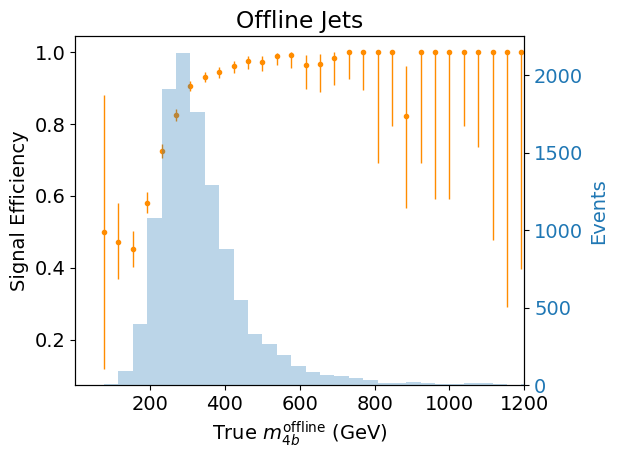

In [143]:
fig, ax1 = plt.subplots()

ax1.set_xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')

ax1.set_ylabel('Signal Efficiency')
ax1.errorbar(mass, signal_efficiency, yerr=[err_low, err_upp], fmt='.', elinewidth=1, color='darkorange')
#ax1.tick_params(axis='y', labelcolor='darkorange')

ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

ax2.set_ylabel('Events', color= colors[4])  # we already handled the x-label with ax1
ax2.hist(signal_mass, bins=np.linspace(0.1,1500,40), color=colors[4], alpha=0.3)
ax2.tick_params(axis='y', labelcolor=colors[4])
ax1.set_xlim(0.1,1200)
ax1.set_title('Offline Jets')
fig.tight_layout()
plt.show()

In [ ]:
np.savez('offline_jets_lda_mass.npz', energy=mass, signal_eff=signal_efficiency, err_low=err_low, err_upp=err_upp)

# X - PFN

In this section, we apply Particle Flow Networks (PFN) to distinguish signal and background using supervised learning.

In [ ]:
# Convert labels to categorical
# bkg (1,0) and sig (0,1)
y_categorical = to_categorical(y, num_classes=2)

In [ ]:
# Apply padding with all-zero particles such that all events have the same
# number of jets
X_padded = pad_sequences(data_efp, padding='post', dtype='float32', value=0.0)

test_frac = 0.2
signal_idx = np.where(y == 1)[0]
bkg_idx    = np.where(y == 0)[0]

X_sig_train, X_sig_test,  pt4_sig_train, pt4_sig_test, mass_sig_train, mass_sig_test, y_sig_train, y_sig_test = train_test_split(
    X_padded[signal_idx], pt4_offline[signal_idx], true_mass[signal_idx], y_categorical[signal_idx], test_size=0.2, random_state=42
)

X_bkg_train, X_bkg_test, pt4_bkg_train, pt4_bkg_test, mass_bkg_train, mass_bkg_test, y_bkg_train, y_bkg_test = train_test_split(
    X_padded[bkg_idx], pt4_offline[bkg_idx], true_mass[bkg_idx], y_categorical[bkg_idx], test_size=0.2, random_state=42
)

X_train = np.concatenate([X_sig_train, X_bkg_train])
y_train = np.concatenate([y_sig_train, y_bkg_train])

X_test  = np.concatenate([X_sig_test,  X_bkg_test])
y_test  = np.concatenate([y_sig_test,  y_bkg_test])
pt4_test = np.concatenate([pt4_sig_test, pt4_bkg_test])
mass_test = np.concatenate([mass_sig_test, mass_bkg_test])

In [ ]:
# Define masking layer to ensure all zero jets are not considered
masking_layer = tf.keras.layers.Masking(mask_value=0.0)
# Apply masking
masked_X_train = masking_layer(X_train)
masked_X_test = masking_layer(X_test)

# Define and apply normalization layer
scaler_layer = tf.keras.layers.Normalization(axis=-1)
scaler_layer.adapt(masked_X_train)

X_train_norm = scaler_layer(masked_X_train)
X_train_norm = np.array(X_train_norm)

X_test_norm = scaler_layer(masked_X_test)
X_test_norm = np.array(X_test_norm)

In [ ]:
# PFN network architecture parameters
Phi_sizes, F_sizes = (100, 100, 128), (100, 100, 100)
# Phi_sizes, F_sizes = (100, 100, 256), (100, 100, 100)

# PFN network training parameters
num_epoch = 15
batch_size = 500

In [ ]:
# build architecture
pfn = PFN(input_dim=X_train.shape[-1], Phi_sizes=Phi_sizes, F_sizes=F_sizes)

# train model
pfn.fit(X_train_norm, y_train,
        epochs=num_epoch,
        batch_size=batch_size,
        verbose=1)

# get predictions on test data
preds = pfn.predict(X_test_norm)

# get ROC curve
pfn_fp, pfn_tp, threshs = roc_curve(y_test[:,1], preds[:,1])

# get area under the ROC curve
auc = roc_auc_score(y_test[:,1], preds[:,1])
print()
print('PFN AUC:', auc)
print()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input (InputLayer)          [(None, None, 3)]            0         []                            
                                                                                                  
 tdist_0 (TimeDistributed)   (None, None, 100)            400       ['input[0][0]']               
                                                                                                  
 activation (Activation)     (None, None, 100)            0         ['tdist_0[0][0]']             
                                                                                                  
 tdist_1 (TimeDistributed)   (None, None, 100)            10100     ['activation[0][0]']          
                                                                                              

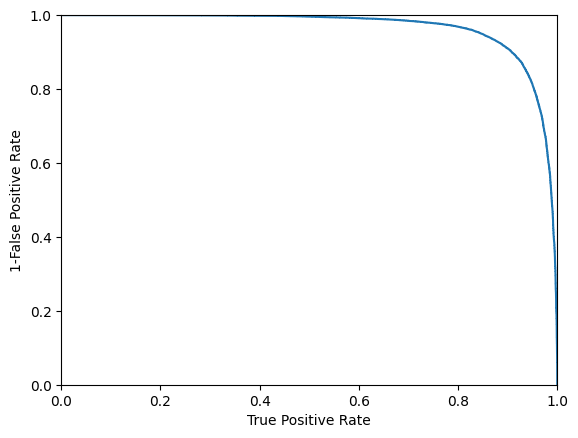


AUC: 0.9646433175



In [ ]:
# Plot ROC curve
pfn_fp, pfn_tp, threshs = roc_curve(y_test[:,1], preds[:,1])
plt.plot(pfn_tp, 1-pfn_fp, '-')
plt.xlabel('True Positive Rate')
plt.ylabel('1-False Positive Rate')
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

# Print AUC
auc = roc_auc_score(y_test[:,1], preds[:,1])
print()
print('AUC:'.format(auc), auc)
print()

In [ ]:
# Divide test set into signal and background events and retrieve corresponding scores
preds_bkg = []
preds_sig = []
for i in range(len(y_test)):
  if y_test[i][1] == 0:
    preds_bkg.append(preds[i][1])
  if y_test[i][1] == 1:
    preds_sig.append(preds[i][1])

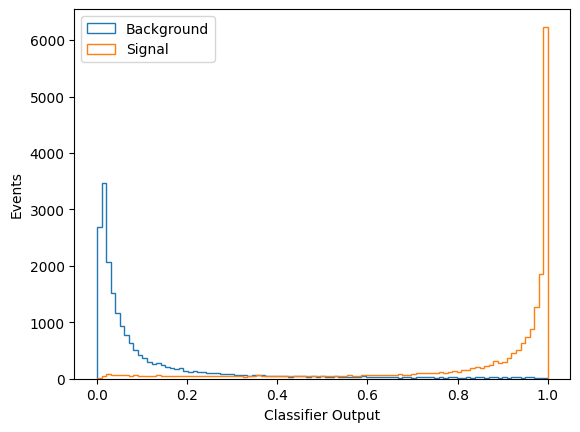

In [ ]:
# Plot classifier output
plot_scores(preds_bkg, preds_sig)

In [ ]:
# Compute the 5% background aceptance threshold
cut = get_threshold(preds_bkg)
print(f'The 5% acceptance threshold is: {cut:.4f}')

The 5% acceptance threshold is: 0.6072


## Energy of the fourth-leading jet

In [ ]:
# Retrieve pT of the fourth leading jet for all signal events
signal_energies = []
for i in range(len(X_test_norm)):
  if y_test[i][1] == 1:
    signal_energies.append(pt4_test[i])

# Retrieve pT of the fourth leading jet for the selected signal events
selected_energies = []
for i in range(len(preds)):
  if preds[i][1] >= cut and y_test[i][1] == 1:
    selected_energies.append(pt4_test[i])

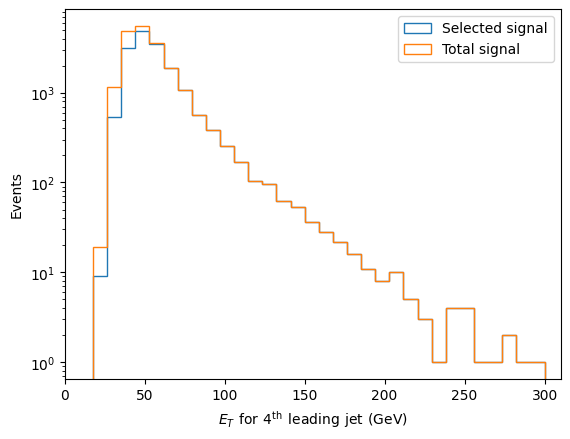

In [ ]:
# Plot distribution of the energy of the fourth leading jet for the selected signal and for all signal events
plt.hist(selected_energies, bins=np.linspace(0.1,300,35), histtype='step', label='Selected signal')
plt.hist(signal_energies, bins=np.linspace(0.1,300,35), histtype='step',label='Total signal')
plt.xlabel(r'$E_{T} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('Events')
plt.yscale('log')
plt.xlim(0,310)
plt.legend()
plt.show()

In [ ]:
bins=np.linspace(0.1,300,35)
selected_counts, edges = np.histogram(selected_energies, bins=bins)
signal_counts, edges1 = np.histogram(signal_energies, bins=bins)
# Define arrays to store the signal efficiency and jet energy
signal_efficiency = []
energy = []
sel_sig_counts = []
sig_counts = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts[i]
  if sig_i != 0:
    sig_counts.append(sig_i)
    sel_sig_counts.append(sel_sig_i)
    signal_efficiency.append(sel_sig_i/sig_i)
    energy.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low, ci_upp = proportion_confint(sel_sig_counts, sig_counts, alpha=0.05, method='beta')
# Compute error bars
err_low = signal_efficiency - ci_low
err_upp = ci_upp - signal_efficiency

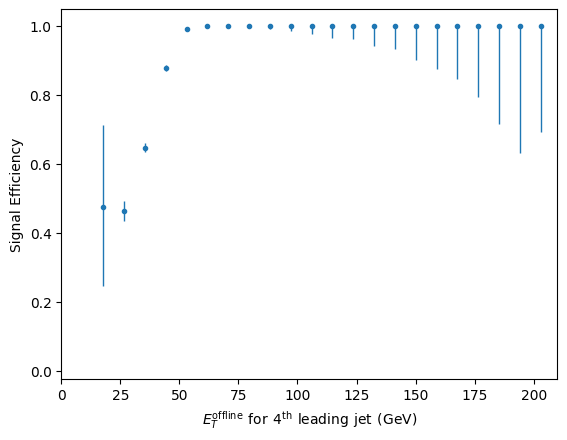

In [ ]:
# Plot signal efficiency as a function of the energy
plt.errorbar(energy, signal_efficiency, yerr=[err_low, err_upp], fmt='.', elinewidth=1)
plt.xlabel(r'$E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('Signal Efficiency')
plt.xlim(0,210)

plt.show()

In [ ]:
np.savez('offline_jets_pfn_pt4.npz', energy=energy, signal_eff=signal_efficiency, err_low=err_low, err_upp=err_upp)

## Invariant mass of the bbbb system

In [ ]:
# Retrieve pT of the fourth leading jet for all signal events
signal_mass = []
selected_mass = []
for i in range(len(X_test)):
  if y_test[i][1] == 1:
    if mass_test[i] != 0:
      signal_mass.append(mass_test[i])
      if preds[i][1] >= cut and y_test[i][1] == 1:
        selected_mass.append(mass_test[i])

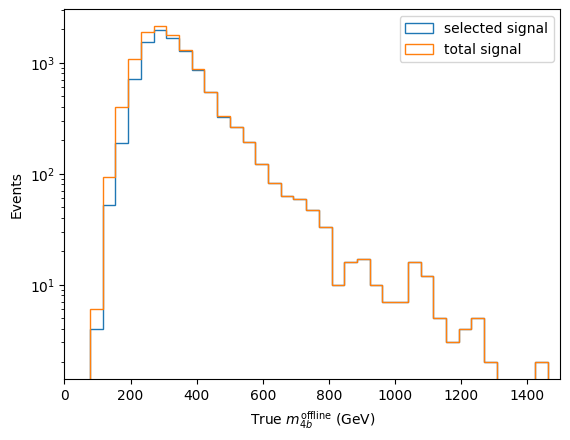

In [ ]:
# Plot distribution of the invariant mass for the selected signal and for all signal events
plt.hist(selected_mass, bins=np.linspace(0.1,1500,40), histtype='step', label='selected signal')
plt.hist(signal_mass, bins=np.linspace(0.1,1500,40), histtype='step',label='total signal')
plt.xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
plt.ylabel('Events')
plt.yscale('log')
plt.xlim(0,1500)
plt.legend()
plt.show()

In [ ]:
# Define histograms of the energies
bins=np.linspace(0.1,1500,40)
selected_counts, edges = np.histogram(selected_mass, bins=bins)
signal_counts, edges1 = np.histogram(signal_mass, bins=bins)
# Define arrays to store the signal efficiency and invariant mass
signal_efficiency = []
mass = []
sel_sig_counts = []
sig_counts = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts[i]
  if sig_i != 0:
    sig_counts.append(sig_i)
    sel_sig_counts.append(sel_sig_i)
    signal_efficiency.append(sel_sig_i/sig_i)
    mass.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low, ci_upp = proportion_confint(sel_sig_counts, sig_counts, alpha=0.05, method='beta')
# Compute error bars
err_low = signal_efficiency - ci_low
err_upp = ci_upp - signal_efficiency

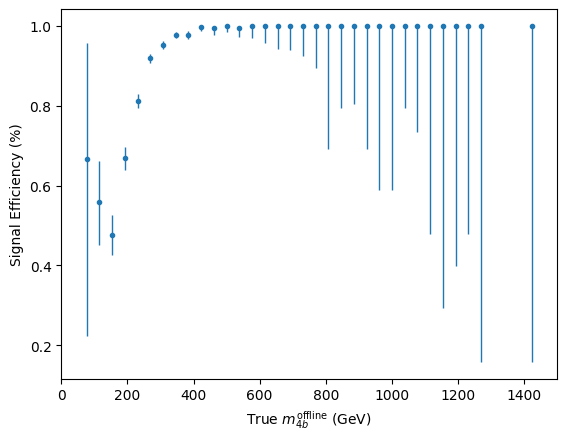

In [ ]:
# Plot signal efficiency as a function of the energy
plt.errorbar(mass, signal_efficiency, yerr=[err_low, err_upp], fmt='.', elinewidth=1)
plt.xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
plt.ylabel('Signal Efficiency (%)')
plt.xlim(0,1500)
plt.show()

In [ ]:
np.savez('offline_jets_pfn_mass.npz', energy=mass, signal_eff=signal_efficiency, err_low=err_low, err_upp=err_upp)

# XI - Baseline pT cut

In this section, we apply a pt cut to distinguish signal and background.




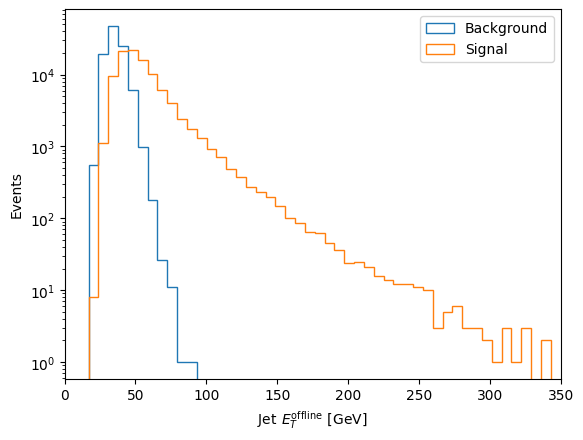

In [ ]:
# Plot distribution of the offline energy of the fourth leading jet
# for signal and background
plt.hist(pt4_bkg_offline, bins = np.linspace(10,350,50), histtype='step', label='Background')
plt.hist(pt4_sig_offline, bins = np.linspace(10,350,50),  histtype='step',label='Signal')
plt.xlim(0, 350)
plt.yscale('log')
plt.xlabel(r'$\mathrm{Jet} \hspace{0.4} E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{[GeV]}$')
plt.ylabel('Events')
plt.legend()
plt.show()

In [ ]:
# Select energy threshold for 5% background acceptance
# Define histogram for bkg ET4(offline)
bins = np.linspace(0.01,300,35)
counts, edges = np.histogram(pt4_bkg_offline, bins = bins)
# Calculate histogram integral
total_integral = np.sum(counts)
# Calculate the bkg efficiency for each threshold
thresholds = []
background_efficiency = []
bkg_counts = 0
for i in range(len(counts)):
  bkg_counts += counts[i]
  if total_integral != 0:
    bkg_acceptance = bkg_counts/total_integral
    background_efficiency.append(bkg_acceptance)
    cut = edges[i+1]
    thresholds.append(cut)
    if bkg_acceptance >= 0.95:
      threshold = cut
      break
print(f'The 5% acceptance threshold is: {threshold:.4f}')

The 5% acceptance threshold is: 52.9494


In [ ]:
tot_sig_energies = []
sel_sig_energies = []

for i in range(len(pt4_sig_offline)):
  if pt4_sig_offline[i] != 0:
    tot_sig_energies.append(pt4_sig_offline[i])
    if pt4_sig_offline[i] >= threshold:
      sel_sig_energies.append(pt4_sig_offline[i])

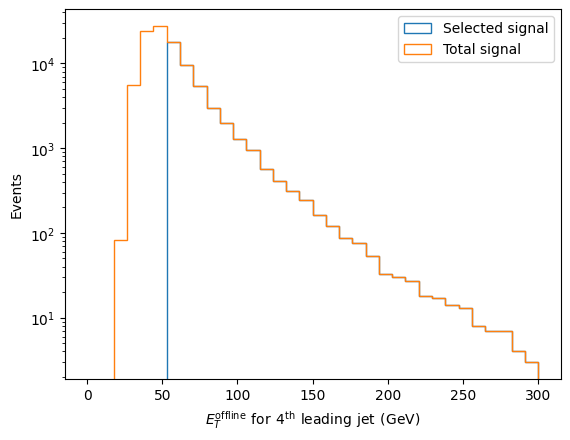

In [ ]:
# Plot distribution of the energy of the fourth leading jet for the selected signal and for all signal events
plt.hist(sel_sig_energies, bins=np.linspace(0.01,300,35), histtype='step', label='Selected signal')
plt.hist(tot_sig_energies, bins=np.linspace(0.01,300,35), histtype='step',label='Total signal')
plt.xlabel(r'$E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
plt.ylabel('Events')
plt.yscale('log')
#plt.xlim(0,320)
plt.legend()
plt.show()

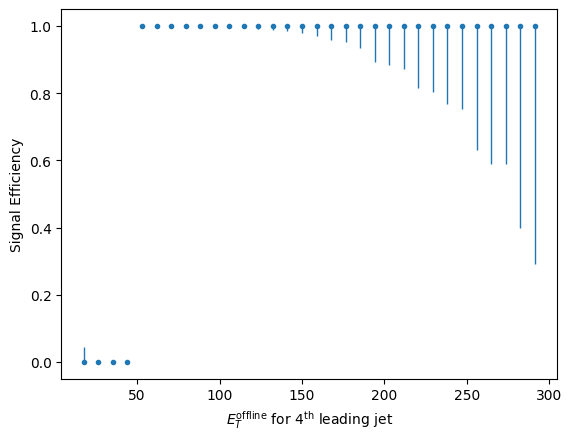

In [ ]:
# Define histograms of the energies
bins=np.linspace(0.01,300,35)
selected_counts, edges = np.histogram(sel_sig_energies, bins=bins)
signal_counts, edges1 = np.histogram(tot_sig_energies, bins=bins)
# Define arrays to store the signal efficiency and jet energy
signal_efficiency_pt = []
energy_pt = []
sel_sig_counts = []
sig_counts = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts[i]
  if sig_i != 0:
    sig_counts.append(sig_i)
    sel_sig_counts.append(sel_sig_i)
    signal_efficiency_pt.append(sel_sig_i/sig_i)
    energy_pt.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low_pt, ci_upp_pt = proportion_confint(sel_sig_counts, sig_counts, alpha=0.05, method='beta')
# Compute error bars
err_low_pt = signal_efficiency_pt - ci_low_pt
err_upp_pt = ci_upp_pt - signal_efficiency_pt
# Plot signal efficiency as a function of the energy
plt.errorbar(energy_pt, signal_efficiency_pt, yerr=[err_low_pt, err_upp_pt], fmt='.', elinewidth=1)
plt.xlabel(r'$E_{T}^{\mathrm{offline}}$ for $4^{\mathrm{th}}$ leading jet')
plt.ylabel('Signal Efficiency')
plt.show()

In [ ]:
np.savez('baseline_pt4_offline.npz', energy=energy_pt, signal_eff=signal_efficiency_pt, err_low=err_low_pt, err_upp=err_upp_pt)

## Invariant mass of the bbbb system

In [ ]:
# Retrieve pT of the fourth leading jet for all signal events
signal_mass = []
selected_mass = []
for i in range(len(X_test)):
  if y_test[i] == 1:
    if mass_test[i] != 0:
      signal_mass.append(mass_test[i])
      if pt4_test[i] >= threshold:
        selected_mass.append(mass_test[i])

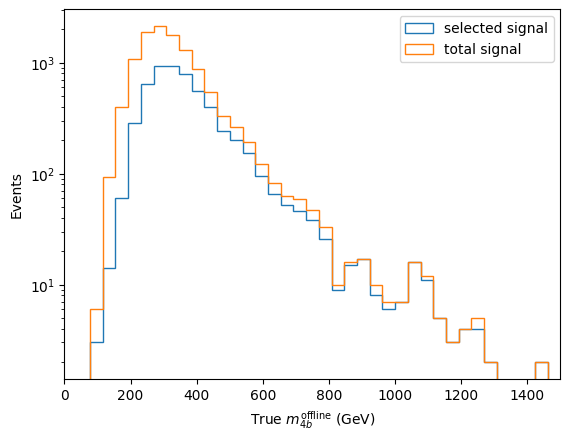

In [ ]:
# Plot distribution of the invariant mass for the selected signal and for all signal events
plt.hist(selected_mass, bins=np.linspace(0.1,1500,40), histtype='step', label='selected signal')
plt.hist(signal_mass, bins=np.linspace(0.1,1500,40), histtype='step',label='total signal')
plt.xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
plt.ylabel('Events')
plt.yscale('log')
plt.xlim(0,1500)
plt.legend()
plt.show()

In [ ]:
# Define histograms of the energies
bins=np.linspace(0.1,1500,40)
selected_counts, edges = np.histogram(selected_mass, bins=bins)
signal_counts, edges1 = np.histogram(signal_mass, bins=bins)
# Define arrays to store the signal efficiency and invariant mass
signal_efficiency = []
mass = []
sel_sig_counts = []
sig_counts = []
# Compute the signal efficiency for each bin of energy
for i in range(len(selected_counts)):
  sig_i = signal_counts[i]
  sel_sig_i = selected_counts[i]
  if sig_i != 0:
    sig_counts.append(sig_i)
    sel_sig_counts.append(sel_sig_i)
    signal_efficiency.append(sel_sig_i/sig_i)
    mass.append(edges[i])
# Compute upper and lower limits for the 95% CI
ci_low, ci_upp = proportion_confint(sel_sig_counts, sig_counts, alpha=0.05, method='beta')
# Compute error bars
err_low = signal_efficiency - ci_low
err_upp = ci_upp - signal_efficiency

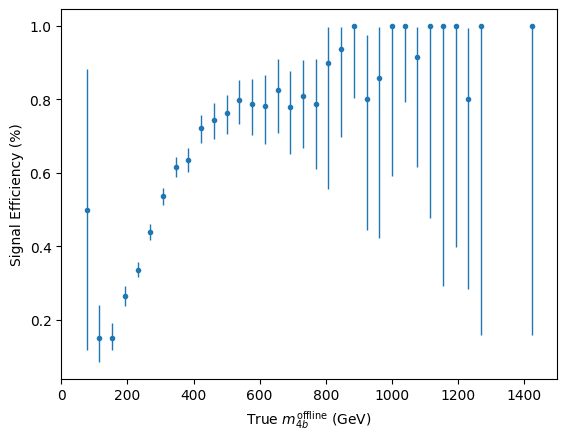

In [ ]:
# Plot signal efficiency as a function of the energy
plt.errorbar(mass, signal_efficiency, yerr=[err_low, err_upp], fmt='.', elinewidth=1)
plt.xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
plt.ylabel('Signal Efficiency (%)')
plt.xlim(0,1500)
plt.show()

In [ ]:
np.savez('baseline_mass_offline.npz', energy=mass, signal_eff=signal_efficiency, err_low=err_low, err_upp=err_upp)

# XII - Turn-on comparison (Offline Jets)

In this section, we compare the turn-on curves for the different selection methods.

In [111]:
offline_jets_lda_pt4 = np.load('offline_jets_lda_pt4.npz')
offline_energy = offline_jets_lda_pt4['energy']
offline_signal_efficiency = offline_jets_lda_pt4['signal_eff']
offline_err_low = offline_jets_lda_pt4['err_low']
offline_err_upp = offline_jets_lda_pt4['err_upp']

In [112]:
baseline_pt4 = np.load('baseline_pt4_offline.npz')
baseline_energy = baseline_pt4['energy']
baseline_signal_efficiency = baseline_pt4['signal_eff']
baseline_err_low = baseline_pt4['err_low']
baseline_err_upp = baseline_pt4['err_upp']

In [113]:
offline_jets_pfn_pt4 = np.load('offline_jets_pfn_pt4.npz')
energy_pfn = offline_jets_pfn_pt4['energy']
signal_efficiency_pfn = offline_jets_pfn_pt4['signal_eff']
err_low_pfn = offline_jets_pfn_pt4['err_low']
err_upp_pfn = offline_jets_pfn_pt4['err_upp']

In [114]:
EFP43_pt4 = np.load('EFP43_pt4_offline.npz')
EFP43_energy = EFP43_pt4['energy']
EFP43_signal_efficiency = EFP43_pt4['signal_eff']
EFP43_err_low = EFP43_pt4['err_low']
EFP43_err_upp = EFP43_pt4['err_upp']

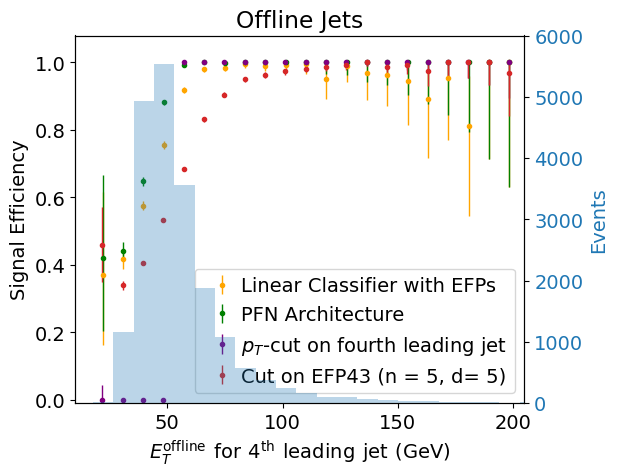

In [115]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel(r'$E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
ax1.set_xlim(10,205)
ax1.set_ylabel('Signal Efficiency')
ax1.errorbar(offline_energy+4.2, offline_signal_efficiency, yerr=[offline_err_low, offline_err_upp],
             fmt='.', elinewidth=1, color='orange', label='Linear Classifier with EFPs')
ax1.errorbar(energy_pfn+4.2, signal_efficiency_pfn, yerr=[err_low_pfn, err_upp_pfn],
             fmt='.', elinewidth=1, color='green', label='PFN Architecture')
ax1.errorbar(baseline_energy+4.2, baseline_signal_efficiency, yerr=[baseline_err_low, baseline_err_upp],
             fmt='.', elinewidth=1, color='purple', label=(r'$p_T$-cut on fourth leading jet'))
ax1.errorbar(EFP43_energy+4.2, EFP43_signal_efficiency, yerr=[EFP43_err_low, EFP43_err_upp],
             fmt='.', elinewidth=1, color='tab:red', label='Cut on EFP43 (n = 5, d= 5)')

ax2 = ax1.twinx()
ax1.set_ylim(-0.01,1.08)
ax2.set_ylim(0,6000)
ax2.set_ylabel('Events', color= colors[4])
ax2.hist(signal_energies, bins=np.linspace(0.1,300,35), color=colors[4], alpha=0.3)
ax2.tick_params(axis='y', labelcolor=colors[4])
ax1.legend(loc='best', handletextpad=0)
fig.tight_layout()
plt.title('Offline Jets')
plt.show()

## Invariant mass

In [116]:
offline_jets_lda_mass = np.load('offline_jets_lda_mass.npz')
offline_energy = offline_jets_lda_mass['energy']
offline_signal_efficiency = offline_jets_lda_mass['signal_eff']
offline_err_low = offline_jets_lda_mass['err_low']
offline_err_upp = offline_jets_lda_mass['err_upp']

In [117]:
baseline_mass = np.load('baseline_mass_offline.npz')
baseline_energy = baseline_mass['energy']
baseline_signal_efficiency = baseline_mass['signal_eff']
baseline_err_low = baseline_mass['err_low']
baseline_err_upp = baseline_mass['err_upp']

In [118]:
offline_jets_pfn_mass = np.load('offline_jets_pfn_mass.npz')
energy_pfn = offline_jets_pfn_mass['energy']
signal_efficiency_pfn = offline_jets_pfn_mass['signal_eff']
err_low_pfn = offline_jets_pfn_mass['err_low']
err_upp_pfn = offline_jets_pfn_mass['err_upp']

In [119]:
EFP43_mass = np.load('EFP43_mass_offline.npz')
EFP43_energy = EFP43_mass['energy']
EFP43_signal_efficiency = EFP43_mass['signal_eff']
EFP43_err_low = EFP43_mass['err_low']
EFP43_err_upp = EFP43_mass['err_upp']

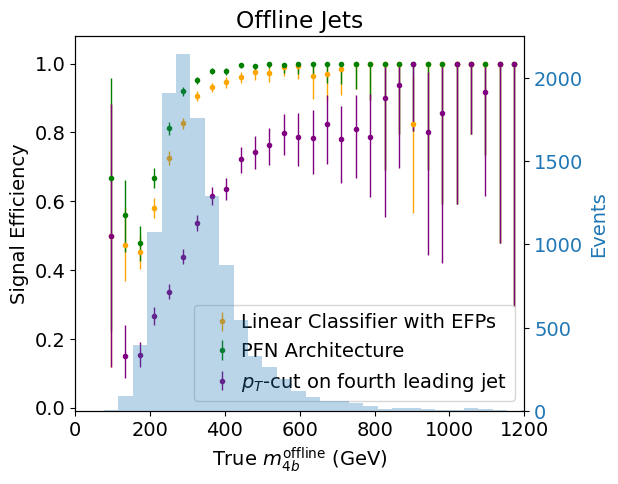

In [120]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
ax1.set_ylabel('Signal Efficiency')
ax1.errorbar(offline_energy+18.75, offline_signal_efficiency, yerr=[offline_err_low, offline_err_upp],
             fmt='.', elinewidth=1, color='orange', label='Linear Classifier with EFPs')
ax1.errorbar(energy_pfn+18.75, signal_efficiency_pfn, yerr=[err_low_pfn, err_upp_pfn],
             fmt='.', elinewidth=1, color='green', label='PFN Architecture')
ax1.errorbar(baseline_energy+18.75, baseline_signal_efficiency, yerr=[baseline_err_low, baseline_err_upp],
             fmt='.', elinewidth=1, color='purple', label=(r'$p_T$-cut on fourth leading jet'))
#ax1.errorbar(EFP43_energy+18.75, EFP43_signal_efficiency, yerr=[EFP43_err_low, EFP43_err_upp],
#             fmt='.', elinewidth=1, color='tab:red', label='Cut on EFP43 (n = 5, d= 5)')

ax2 = ax1.twinx()
ax1.set_ylim(-0.01,1.08)
#ax2.set_ylim(0,6000)
ax1.set_xlim(0,1200)
ax2.set_ylabel('Events', color= colors[4])
ax2.hist(signal_mass, bins=np.linspace(0.1,1500,40), color=colors[4], alpha=0.3)
ax2.tick_params(axis='y', labelcolor=colors[4])
ax1.legend(loc='best', handletextpad=0)
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('Offline Jets')
plt.show()

# XIII - Turn-on comparison (L1 Trigger Jets)

In [168]:
trigger_jets_lda_pt4 = np.load('trigger_jets_lda_pt4.npz')
trigger_energy = trigger_jets_lda_pt4['energy']
trigger_signal_efficiency = trigger_jets_lda_pt4['signal_eff']
trigger_err_low = trigger_jets_lda_pt4['err_low']
trigger_err_upp = trigger_jets_lda_pt4['err_upp']

In [169]:
baseline_pt4 = np.load('baseline_pt4_trigger.npz')
baseline_energy = baseline_pt4['energy']
baseline_signal_efficiency = baseline_pt4['signal_eff']
baseline_err_low = baseline_pt4['err_low']
baseline_err_upp = baseline_pt4['err_upp']

In [170]:
trigger_jets_pfn_pt4 = np.load('trigger_jets_pfn_pt4.npz')
energy_pfn = trigger_jets_pfn_pt4['energy']
signal_efficiency_pfn = trigger_jets_pfn_pt4['signal_eff']
err_low_pfn = trigger_jets_pfn_pt4['err_low']
err_upp_pfn = trigger_jets_pfn_pt4['err_upp']

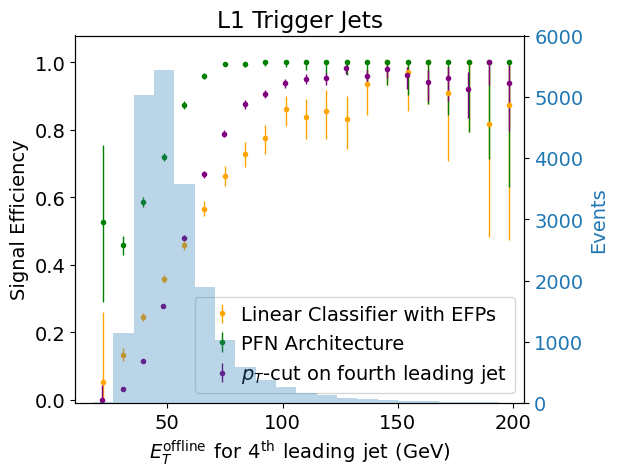

In [171]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel(r'$E_{T}^{\mathrm{offline}} \hspace{0.4} \mathrm{for} \hspace{0.4} 4^{\mathrm{th}} \hspace{0.4} \mathrm{leading} \hspace{0.4} \mathrm{jet} \hspace{0.4} \mathrm{(GeV)}$')
ax1.set_xlim(10,205)
ax1.set_ylabel('Signal Efficiency')
ax1.errorbar(trigger_energy+4.2, trigger_signal_efficiency, yerr=[trigger_err_low, trigger_err_upp],
             fmt='.', elinewidth=1, color='orange', label='Linear Classifier with EFPs')
ax1.errorbar(energy_pfn+4.2, signal_efficiency_pfn, yerr=[err_low_pfn, err_upp_pfn],
             fmt='.', elinewidth=1, color='green', label='PFN Architecture')
ax1.errorbar(baseline_energy+4.2, baseline_signal_efficiency, yerr=[baseline_err_low, baseline_err_upp],
             fmt='.', elinewidth=1, color='purple', label=(r'$p_T$-cut on fourth leading jet'))

ax2 = ax1.twinx()
ax1.set_ylim(-0.01,1.08)
ax2.set_ylim(0,6000)
ax2.set_ylabel('Events', color= colors[4])
ax2.hist(signal_energies, bins=np.linspace(0.1,300,35), color=colors[4], alpha=0.3)
ax2.tick_params(axis='y', labelcolor=colors[4])
ax1.legend(loc='best', handletextpad=0)
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('L1 Trigger Jets')
plt.show()

## Invariant mass

In [172]:
trigger_jets_lda_mass = np.load('trigger_jets_lda_mass.npz')
trigger_energy = trigger_jets_lda_mass['energy']
trigger_signal_efficiency = trigger_jets_lda_mass['signal_eff']
trigger_err_low = trigger_jets_lda_mass['err_low']
trigger_err_upp = trigger_jets_lda_mass['err_upp']

In [173]:
baseline_mass = np.load('baseline_mass_trigger.npz')
baseline_energy = baseline_mass['energy']
baseline_signal_efficiency = baseline_mass['signal_eff']
baseline_err_low = baseline_mass['err_low']
baseline_err_upp = baseline_mass['err_upp']

In [174]:
trigger_jets_pfn_mass = np.load('trigger_jets_pfn_mass.npz')
energy_pfn = trigger_jets_pfn_mass['energy']
signal_efficiency_pfn = trigger_jets_pfn_mass['signal_eff']
err_low_pfn = trigger_jets_pfn_mass['err_low']
err_upp_pfn = trigger_jets_pfn_mass['err_upp']

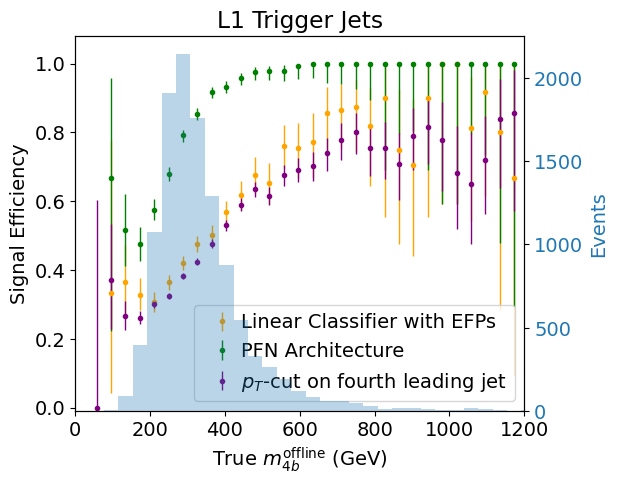

In [175]:
fig, ax1 = plt.subplots()

color = 'tab:red'
ax1.set_xlabel(r'True $m_{4b}^{\mathrm{offline}}$ (GeV)')
ax1.set_ylabel('Signal Efficiency')
ax1.errorbar(trigger_energy+18.75, trigger_signal_efficiency, yerr=[trigger_err_low, trigger_err_upp],
             fmt='.', elinewidth=1, color='orange', label='Linear Classifier with EFPs')
ax1.errorbar(energy_pfn+18.75, signal_efficiency_pfn, yerr=[err_low_pfn, err_upp_pfn],
             fmt='.', elinewidth=1, color='green', label='PFN Architecture')
ax1.errorbar(baseline_energy+18.75, baseline_signal_efficiency, yerr=[baseline_err_low, baseline_err_upp],
             fmt='.', elinewidth=1, color='purple', label=(r'$p_T$-cut on fourth leading jet'))

ax2 = ax1.twinx()
ax1.set_ylim(-0.01,1.08)
#ax2.set_ylim(0,6000)
ax1.set_xlim(0,1200)
ax2.set_ylabel('Events', color= colors[4])
ax2.hist(signal_mass, bins=np.linspace(0.1,1500,40), color=colors[4], alpha=0.3)
ax2.tick_params(axis='y', labelcolor=colors[4])
ax1.legend(loc='best', handletextpad=0)
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title('L1 Trigger Jets')
plt.show()